# \(B^\pm\to K^\pm K^\pm K^\mp\) — ajuste CP com QMI2D

Este notebook substitui o QMI 1D por um campo complexo **bidimensional**,
`DalitzAmplitude("QMI2D", ...)`, mantendo os componentes isóbaros explícitos,
os coeficientes `CPRealImag`, os dados, os vetos, a eficiência e os fundos.

A ordem das filhas continua `('K+', 'K+', 'K-')` para B+ e sua conjugada para B-.
Portanto, os invariantes de cargas opostas são **s13 e s23**. Um adaptador
repassa esses invariantes ao QMI2D, que usa
\(s_\mathrm{low}=\min(s_{13},s_{23})\) e
\(s_\mathrm{high}=\max(s_{13},s_{23})\), com `folded=True`.
A integração e o ajuste continuam no plano completo. Não há um segundo fator
de simetrização nem divisão do coeficiente por dois no `DalitzAmplitude`.

**Interpretação:** um campo 2D livre não é uma S-wave pura. Ele pode absorver
estrutura angular e interferir/competir com as ressonâncias explícitas.
As frações passam a se referir ao componente QMI2D; não devem ser rotuladas como
frações de S-wave. `chi(c0)(1P)` continua sendo uma ressonância separada.

- As magnitudes e fases das células são compartilhadas entre B+ e B-; CPV
  permanece no coeficiente global do campo, sem parâmetros CP por célula.
- Uma célula de referência bem ocupada tem magnitude 1 e fase 0 fixas;
  isso remove a redundância entre escala/fase do campo e seu coeficiente.
  `phi(1020)` mantém a referência global do modelo coerente.
- Os valores iniciais vêm da soma isóbara antiga em **pontos físicos 2D**,
  próximos aos centros das células. Células de fronteira podem ter centros
  fora do Dalitz: nesses casos usamos um ponto interior da mesma célula.
  É apenas uma semente, não uma igualdade exata entre os modelos interpolados.
- `normalize_components=False` mantém a escala bruta dos componentes; a
  normalização total e todas as interferências continuam sendo calculadas.
- Massas, larguras e vínculos Gaussianos das ressonâncias seguem a tabela
  `particle2026.csv` carregada abaixo. O QMI2D não tem massa, largura ou spin.

O número de parâmetros é mostrado ao construir a sessão. Verifique estabilidade
com outras malhas, sementes, resoluções e covariância antes de interpretar os
resultados. As saídas do ajuste 1D foram removidas; o novo ajuste deve ser executado.


In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"


# Já é o padrão; útil se essa opção estava desabilitada.
flags = os.environ.get("XLA_FLAGS", "")
os.environ["XLA_FLAGS"] = (
    flags + " --xla_cpu_multi_thread_eigen=true"
).strip()

os.environ["JAX_PLATFORMS"] = "cuda" # cpu, gpu, tpu

In [2]:

from dataclasses import dataclass, replace
from pathlib import Path
import inspect

from particle import Particle, data as particle_data

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dalitzplotfitter import (
    BaBarFlatte,
    CompositeVeto,
    CPFitSession,
    CPRealImag,
    DalitzAmplitude,
    GaussianConstraint,
    MassWindowVeto,
    QMI2D,
    physical_bin_mask,
    dalitz_s13_limits,
    PhaseSpaceSample,
    DecayChannel,
    DecayModel,
    Parameter,
    PhaseSpaceMC,
    RealImag,
    Resonance,
    Rescattering2,
    SquareDalitzHistogramBackground,
    SquareDalitzHistogramEfficiency,
    YieldAsymmetry,
    GounarisSakurai,
    enable_x64,
    plot_pulls,
    read_phase_space_sample,
    read_root_tree,
)

enable_x64()

# Pin every Resonance mass/width sourced from the `particle` package below
# to the 2026 PDG snapshot explicitly, rather than relying on whatever table
# version happens to be `particle`'s own current default -- reproducible even
# if a future `particle` release changes that default.
Particle.load_table(particle_data.basepath / 'particle2026.csv', append=False)
print('particle tables:', Particle.table_names())

# Fail early if an older checkout is accidentally used.
_fit_signature = inspect.signature(CPFitSession.fit)
if not {'strategy', 'hesse', 'hessian'} <= _fit_signature.parameters.keys():
    raise RuntimeError(
        "This notebook requires the current DalitzPlotFitter main branch: "
        "CPFitSession.fit must expose strategy=, hesse= and hessian=."
    )


particle tables: ('/home/juan-leite/Work/DalitzPlotFitter/.venv/lib/python3.14/site-packages/particle/data/particle2026.csv',)


## Configuration

In [3]:
ROOT_FILE = Path('/home/juan-leite/Work/data/B2KKK_data.root')
TREE_NAME = 'DecayTree'

MC_FILE = Path('/home/juan-leite/Work/data/mclarge151617_kkk.root')
MC_TREE_NAME = 'DecayTree'

BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    's12': 's12',
    's13': 's31',
    's23': 's23',
    # Already-folded Square-Dalitz coordinates (thPrime in [0, 0.5]).
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
}

MC_BRANCH = {
    'mass': 'B_m',
    'charge': 'B_charge',
    'mprime': 'mPrime',
    'thetaprime': 'thPrime',
    'pid_eff': 'Event_PIDCalibEff',
}

INVARIANT_UNIT = 'GeV2'

BPLUS_CHARGE_VALUE = +1
BMINUS_CHARGE_VALUE = -1

SIGNAL_MASS_WINDOW = (5247.0, 5315.0)
BKG_MASS_MIN = 5500.0

D0_MASS_GEV = 1.86484
D0_VETO_HALF_WIDTH_GEV = 0.030

# J/psi(1S) -> K+K- veto, same window convention as the D0 veto above
# (configurable half-width, applied to both opposite-sign K+K- pairings and
# both charges); the model itself no longer fits a Jpsi_1S component.
JPSI_MASS_GEV = 3.096900
JPSI_VETO_HALF_WIDTH_GEV = 0.010

def pdg_mass_width(particle_name):
    """Mass/width (GeV) and their PDG uncertainty (GeV), pinned to PDG
    2026 by the `Particle.load_table(...)` call above. `particle_name` must
    be the exact string the `particle` package resolves via
    `Particle.from_name` (e.g. 'rho(1450)0', not an internal component
    label like 'rho0_1450') -- this is also why every resonance below is
    named after its `particle`-recognized string directly.
    """
    particle = Particle.from_name(particle_name)
    mass_sigma = 0.5 * (particle.mass_lower + particle.mass_upper)
    width_sigma = 0.5 * (particle.width_lower + particle.width_upper)
    return dict(
        mass=particle.mass / 1000.0,
        mass_sigma=mass_sigma / 1000.0,
        width=particle.width / 1000.0,
        width_sigma=width_sigma / 1000.0,
    )


# rho(1450)0/rho(1700)0/phi(1020)/chi(c0)(1P) mass and width: PDG-2026
# central values and uncertainties (pdg_mass_width above), used both as
# the nominal Resonance mass/width and as the mean/sigma of a
# GaussianConstraint in build_models() below. Each FREE_*_MASS_WIDTH flag
# keeps that resonance's mass/width fixed at the PDG central value
# (default) or floats it, still penalized by the same Gaussian constraint
# around the PDG value either way.
FREE_RHO_1450_1700_MASS_WIDTH = False
FREE_PHI1020_MASS_WIDTH = False
FREE_CHIC0_MASS_WIDTH = False

RHO0_1450_PDG = pdg_mass_width('rho(1450)0')
RHO0_1700_PDG = pdg_mass_width('rho(1700)0')
PHI1020_PDG = pdg_mass_width('phi(1020)')
CHIC0_PDG = pdg_mass_width('chi(c0)(1P)')

# rho0(770)/f2'(1525)/phi(1680): PDG-2026 mass/width, not Gaussian-
# constrained (kept fixed, as plain floats, matching the previous
# hard-coded values) -- only their *source* changes here, from typed
# literals to a live particle lookup.
RHO0_770_PDG = pdg_mass_width('rho(770)0')
F2P_1525_PDG = pdg_mass_width("f(2)'(1525)")
PHI1680_PDG = pdg_mass_width('phi(1680)')

M_B_GEV = 5.27934
M_K_GEV = 0.493677
DAUGHTER_MASSES = (M_K_GEV, M_K_GEV, M_K_GEV)

# The two identical K+ are particles (0, 1) in ('K+', 'K+', 'K-'); this is
# the pair that must be used for the Square-Dalitz (m', theta') convention
# for `folded=True` to be valid (exchanging it leaves m' fixed and maps
# theta' -> 1 - theta'), and it matches the pair used to compute the ROOT
# files' own mPrime/thPrime branches (verified numerically against B_m).
# Used both for the goodness_of_fit_chi2(square_dalitz=True) postfit checks
# and for the folded background/efficiency Square-Dalitz histograms below.
SQDP_PAIR = (0, 1)

# (mPrime bins, thetaPrime-half bins): mPrime spans [0, 1], thetaPrime spans
# [0, 0.5] since the histograms are built directly from the already-folded
# ROOT mPrime/thPrime branches and evaluated with folded=True.
SEPARATE_BKG_BY_CHARGE = False
BACKGROUND_BINS = (45, 45)
BACKGROUND_SMOOTH_SIGMA = 1.0

USE_EFFICIENCY = True
EFFICIENCY_BINS = (45, 45)
EFFICIENCY_SMOOTH_SIGMA = 1.0

# Extended fit: N_signal, A_yield and N_combinatorial are known from an
# external measurement (e.g. an extended ML fit to the B mass spectrum) and
# are fixed (not floated) in this Dalitz fit -- only the amplitude
# parameters are free. YieldAsymmetry's raw counting asymmetry
# A_yield = (N_minus - N_plus) / N_s is independent of CPRealImag's
# coefficient-level A_CP (see docs/cp_coefficients.md).
SIGNAL_YIELD = 323_514  # TODO: set to the known N_signal
YIELD_ASYMMETRY = -0.037  # TODO: set to the known A_yield
BACKGROUND_YIELD =  11_826 + 30 # TODO: set to the known N_combinatorial

FIT_NSTARTS = 1
FIT_SEED = 20260903
FIT_TOLERANCE = 1e-4
FIT_VERBOSE = 3
FIT_STRATEGY = 1
# Automatic second derivatives also serve HESSE inside MIGRAD. The first
# call compiles a separate JAX program; subsequent calls reuse it.
# Requires iminuit >= 2.32. Use 'numerical' for the previous HESSE path.
FIT_HESSIAN = 'jax'

PROJECTION_SIZE = 2_000_000
PROJECTION_BINS = 100

# Common edges in invariant mass SQUARED, GeV², for both folded axes.
# Low-mass structure gets finer bins; phi(1020) and chi_c0 remain explicit.
QMI2D_THRESHOLD_GEV = 2.0 * M_K_GEV
QMI2D_UPPER_EDGE_GEV = M_B_GEV - M_K_GEV
QMI2D_EDGES_GEV2 = (
    QMI2D_THRESHOLD_GEV**2,
    1.10, 1.40, 1.80, 2.30, 3.20, 4.00,
    6.00, 9.00, 12.00, 16.00, 20.00,
    QMI2D_UPPER_EDGE_GEV**2,
)
QMI2D_INTERPOLATION = 'linear'  # 'none', 'linear', 'cubic'; no 'hermite'
QMI2D_ANCHOR_CELL = (0, 9)  # s_low in [threshold,1.10], s_high in [12,16]
QMI2D_MIN_EVENTS_REVIEW = 100  # per charge; diagnostic, not an automatic cut


## Load unfolded signal data and folded sideband SqDP

In [4]:
def signal_cut(charge=None):
    lo, hi = SIGNAL_MASS_WINDOW
    cut = f"({BRANCH['mass']} >= {lo}) & ({BRANCH['mass']} <= {hi})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def sideband_cut(charge=None):
    cut = f"({BRANCH['mass']} > {BKG_MASS_MIN})"
    if charge is not None:
        cut += f" & ({BRANCH['charge']} == {charge})"
    return cut


def convert_to_gev2(sample):
    if INVARIANT_UNIT == 'GeV2':
        return sample
    if INVARIANT_UNIT != 'MeV2':
        raise ValueError("INVARIANT_UNIT must be 'GeV2' or 'MeV2'")

    scale = 1e-6
    return PhaseSpaceSample(
        s12=jnp.asarray(sample.s12) * scale,
        s13=jnp.asarray(sample.s13) * scale,
        s23=jnp.asarray(sample.s23) * scale,
        weights=jnp.asarray(sample.weights),
        p1=sample.p1,
        p2=sample.p2,
        p3=sample.p3,
    )


def load_signal_sample(charge):
    sample = read_phase_space_sample(
        ROOT_FILE,
        TREE_NAME,
        s12=BRANCH['s12'],
        s13=BRANCH['s13'],
        s23=BRANCH['s23'],
        cut=signal_cut(charge),
    )
    return convert_to_gev2(sample)


def load_sideband_sqdp(charge):
    """Sideband events' already-folded (mPrime, thPrime), read directly."""
    return read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=sideband_cut(charge),
    )


def _mass_veto(mass_gev, half_width_gev):
    """CompositeVeto removing |m(KK) - mass_gev| <= half_width_gev in both
    opposite-sign K+K- pairings ((0,2) and (1,2))."""
    return CompositeVeto(
        MassWindowVeto((0, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
        MassWindowVeto((1, 2), mass_gev - half_width_gev, mass_gev + half_width_gev),
    )


D0_VETO = _mass_veto(D0_MASS_GEV, D0_VETO_HALF_WIDTH_GEV)
JPSI_VETO = _mass_veto(JPSI_MASS_GEV, JPSI_VETO_HALF_WIDTH_GEV)
CHARM_VETO = CompositeVeto(D0_VETO, JPSI_VETO)

_samples_before_veto = {
    'plus': load_signal_sample(BPLUS_CHARGE_VALUE),
    'minus': load_signal_sample(BMINUS_CHARGE_VALUE),
}
_samples_after_d0 = {
    charge: D0_VETO.apply(sample)
    for charge, sample in _samples_before_veto.items()
}
samples = {
    charge: JPSI_VETO.apply(sample)
    for charge, sample in _samples_after_d0.items()
}

for charge in ('plus', 'minus'):
    before = _samples_before_veto[charge].size
    after_d0 = _samples_after_d0[charge].size
    after_jpsi = samples[charge].size
    print(
        f"D0->KK veto   {charge:5s}: removed {before-after_d0:,} / {before:,} "
        f"events in |m(KK)-m(D0)| <= {1000.0*D0_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )
    print(
        f"J/psi->KK veto {charge:5s}: removed {after_d0-after_jpsi:,} / {after_d0:,} "
        f"events in |m(KK)-m(J/psi)| <= {1000.0*JPSI_VETO_HALF_WIDTH_GEV:.0f} MeV"
    )


def load_signal_sqdp(charge_value, charge_key):
    """Signal-window (mPrime, thPrime), masked to match samples[charge_key]
    exactly: same signal_cut, then the same CHARM_VETO acceptance computed
    from the s13/s23 branches read alongside."""
    raw = read_root_tree(
        ROOT_FILE,
        TREE_NAME,
        {
            's13': BRANCH['s13'],
            's23': BRANCH['s23'],
            'mprime': BRANCH['mprime'],
            'thetaprime': BRANCH['thetaprime'],
        },
        cut=signal_cut(charge_value),
    )
    mask = np.asarray(
        CHARM_VETO.accept({'s13': jnp.asarray(raw['s13']), 's23': jnp.asarray(raw['s23'])})
    )
    coords = {
        'mprime': np.asarray(raw['mprime'])[mask],
        'thetaprime': np.asarray(raw['thetaprime'])[mask],
    }
    if coords['mprime'].size != samples[charge_key].size:
        raise RuntimeError(
            f"{charge_key}: signal_sqdp size {coords['mprime'].size} != "
            f"samples size {samples[charge_key].size}"
        )
    return coords


signal_sqdp = {
    'plus': load_signal_sqdp(BPLUS_CHARGE_VALUE, 'plus'),
    'minus': load_signal_sqdp(BMINUS_CHARGE_VALUE, 'minus'),
}

bkg_sqdp = {
    'plus': load_sideband_sqdp(BPLUS_CHARGE_VALUE),
    'minus': load_sideband_sqdp(BMINUS_CHARGE_VALUE),
    'all': load_sideband_sqdp(None),
}

raw_control = read_root_tree(
    ROOT_FILE,
    TREE_NAME,
    {'mass': BRANCH['mass'], 'charge': BRANCH['charge']},
)
raw_control = {name: np.asarray(values) for name, values in raw_control.items()}

print(f"B+ signal events: {samples['plus'].size:,}")
print(f"B- signal events: {samples['minus'].size:,}")
print(f"ROOT candidates:  {len(raw_control['mass']):,}")
def mc_signal_cut(charge):
    """Use exactly the data signal-mass window and one B charge."""
    lo, hi = SIGNAL_MASS_WINDOW
    return (
        f"({MC_BRANCH['mass']} >= {lo}) & "
        f"({MC_BRANCH['mass']} <= {hi}) & "
        f"({MC_BRANCH['charge']} == {charge})"
    )


def load_efficiency_mc(charge):
    """Load the already-folded (mPrime, thPrime) and PID weight from MC."""
    return read_root_tree(
        MC_FILE,
        MC_TREE_NAME,
        {
            'mprime': MC_BRANCH['mprime'],
            'thetaprime': MC_BRANCH['thetaprime'],
            'pid_eff': MC_BRANCH['pid_eff'],
        },
        cut=mc_signal_cut(charge),
    )


def sanitize_efficiency_mc(coords, charge_label):
    """Remove entries that cannot contribute to a physical efficiency map."""
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)

    finite_mp = np.isfinite(mp)
    finite_tp = np.isfinite(tp)
    finite_pid = np.isfinite(pid_eff)

    valid = (
        finite_mp
        & finite_tp
        & finite_pid
        & (mp >= 0.0)
        & (mp <= 1.0)
        & (tp >= 0.0)
        & (tp <= 0.5)
        & (pid_eff > 0.0)
    )

    n_total = int(mp.size)
    n_valid = int(np.count_nonzero(valid))
    n_removed = n_total - n_valid

    print(f"\nEfficiency MC sanitation: {charge_label}")
    print(f"  total in mass/charge selection : {n_total:,}")
    print(f"  valid for efficiency map       : {n_valid:,}")
    print(
        f"  removed                        : {n_removed:,} "
        f"({100.0*n_removed/max(n_total,1):.5f}%)"
    )
    print(f"    non-finite mPrime             : {np.count_nonzero(~finite_mp):,}")
    print(f"    non-finite thPrime            : {np.count_nonzero(~finite_tp):,}")
    print(f"    non-finite Event_PIDCalibEff  : {np.count_nonzero(~finite_pid):,}")
    print(
        "    finite PID efficiency <= 0    : "
        f"{np.count_nonzero(finite_pid & (pid_eff <= 0.0)):,}"
    )

    if n_valid == 0:
        raise RuntimeError(f"{charge_label}: no valid efficiency-MC events")

    return {
        'mprime': jnp.asarray(mp[valid]),
        'thetaprime': jnp.asarray(tp[valid]),
        'pid_eff': jnp.asarray(pid_eff[valid]),
    }


efficiency_mc_raw = {
    'plus': load_efficiency_mc(BPLUS_CHARGE_VALUE),
    'minus': load_efficiency_mc(BMINUS_CHARGE_VALUE),
}

efficiency_mc = {
    'plus': sanitize_efficiency_mc(efficiency_mc_raw['plus'], 'B+'),
    'minus': sanitize_efficiency_mc(efficiency_mc_raw['minus'], 'B-'),
}

print(f"\nEfficiency MC retained B+: {len(efficiency_mc['plus']['mprime']):,}")
print(f"Efficiency MC retained B-: {len(efficiency_mc['minus']['mprime']):,}")

D0->KK veto   plus : removed 0 / 175,996 events in |m(KK)-m(D0)| <= 30 MeV
J/psi->KK veto plus : removed 2,796 / 175,996 events in |m(KK)-m(J/psi)| <= 10 MeV
D0->KK veto   minus: removed 0 / 159,317 events in |m(KK)-m(D0)| <= 30 MeV
J/psi->KK veto minus: removed 2,345 / 159,317 events in |m(KK)-m(J/psi)| <= 10 MeV
B+ signal events: 173,200
B- signal events: 156,972
ROOT candidates:  529,235

Efficiency MC sanitation: B+
  total in mass/charge selection : 1,232,109
  valid for efficiency map       : 1,231,814
  removed                        : 295 (0.02394%)
    non-finite mPrime             : 0
    non-finite thPrime            : 0
    non-finite Event_PIDCalibEff  : 0
    finite PID efficiency <= 0    : 295

Efficiency MC sanitation: B-
  total in mass/charge selection : 1,221,259
  valid for efficiency map       : 1,220,963
  removed                        : 296 (0.02424%)
    non-finite mPrime             : 0
    non-finite thPrime            : 1
    non-finite Event_PIDCalibEff  : 

In [5]:

def validate_inputs():
    for charge, sample in samples.items():
        for variable in ('s12', 's13', 's23'):
            values = np.asarray(getattr(sample, variable), dtype=float)
            if np.any(~np.isfinite(values)):
                raise RuntimeError(f"{charge}: non-finite {variable}")

        s13 = np.asarray(sample.s13, dtype=float)
        s23 = np.asarray(sample.s23, dtype=float)
        print(
            f"{charge:5s}: "
            f"s13=[{s13.min():.4f},{s13.max():.4f}] GeV^2, "
            f"s23=[{s23.min():.4f},{s23.max():.4f}] GeV^2, "
            f"fraction(s13>s23)={np.mean(s13 > s23):.3f}"
        )

    for charge, coords in signal_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if coords['mprime'].size != samples[charge].size:
            raise RuntimeError(f"{charge}: signal_sqdp size mismatch with samples")
        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"{charge}: non-finite mPrime/thPrime")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"{charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"{charge}: thPrime outside [0,0.5]")

        print(
            f"{charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    for charge, coords in bkg_sqdp.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)

        if np.any(~np.isfinite(mp)) or np.any(~np.isfinite(tp)):
            raise RuntimeError(f"BKG {charge}: non-finite SqDP coordinates")
        if np.any((mp < 0.0) | (mp > 1.0)):
            raise RuntimeError(f"BKG {charge}: mPrime outside [0,1]")
        if np.any((tp < 0.0) | (tp > 0.5)):
            raise RuntimeError(f"BKG {charge}: thPrime outside [0,0.5]")

        print(
            f"BKG {charge:5s}: "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}]"
        )

    # Efficiency samples have already been sanitized; these are internal checks.
    for charge, coords in efficiency_mc.items():
        mp = np.asarray(coords['mprime'], dtype=float)
        tp = np.asarray(coords['thetaprime'], dtype=float)
        pid_eff = np.asarray(coords['pid_eff'], dtype=float)

        assert np.all(np.isfinite(mp))
        assert np.all(np.isfinite(tp))
        assert np.all(np.isfinite(pid_eff))
        assert np.all((0.0 <= mp) & (mp <= 1.0))
        assert np.all((0.0 <= tp) & (tp <= 0.5))
        assert np.all(pid_eff > 0.0)

        print(
            f"EFF {charge:5s}: N={len(mp):,}, "
            f"mPrime=[{mp.min():.4f},{mp.max():.4f}], "
            f"thPrime=[{tp.min():.4f},{tp.max():.4f}], "
            f"Event_PIDCalibEff=[{pid_eff.min():.6g},{pid_eff.max():.6g}]"
        )


validate_inputs()


plus : s13=[0.9749,23.1479] GeV^2, s23=[0.9749,23.2030] GeV^2, fraction(s13>s23)=0.500
minus: s13=[0.9750,23.2123] GeV^2, s23=[0.9750,23.2001] GeV^2, fraction(s13>s23)=0.499
plus : mPrime=[0.0179,1.0000], thPrime=[0.0001,0.5000]
minus: mPrime=[0.0157,0.9969], thPrime=[0.0001,0.5000]
BKG plus : mPrime=[0.0132,0.9993], thPrime=[0.0001,0.5000]
BKG minus: mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
BKG all  : mPrime=[0.0101,1.0000], thPrime=[0.0000,0.5000]
EFF plus : N=1,231,814, mPrime=[0.0013,0.9994], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0156231,5.66502]
EFF minus: N=1,220,963, mPrime=[0.0010,1.0000], thPrime=[0.0000,0.5000], Event_PIDCalibEff=[0.0159426,47.6501]


## Folded background/efficiency histograms and display-only Square-Dalitz coordinates

In [6]:

def smooth_histogram(values, sigma):
    values = np.asarray(values, dtype=float)
    if sigma is None or sigma <= 0:
        return values

    from scipy.ndimage import gaussian_filter
    return gaussian_filter(values, sigma=float(sigma), mode='nearest')


def build_background_map(coords, bins=BACKGROUND_BINS, sigma=BACKGROUND_SMOOTH_SIGMA):
    """Already-folded (mPrime, thPrime) sideband histogram -> smoothing ->
    SquareDalitzHistogramBackground(folded=True).

    thPrime in the ROOT files is already folded onto [0, 0.5] for the
    identical-K+ pair SQDP_PAIR, so the histogram is built directly on that
    half-domain; folded=True folds any query point onto it again at
    evaluation time (evaluated from the fit's own s12/s13/s23 via
    invariants_to_square_dalitz), so no explicit mirroring is needed.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    nx, ny = bins

    hist, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)),
    )

    hist = smooth_histogram(hist, sigma)
    hist = np.maximum(hist, 0.0)

    if not np.any(hist > 0.0):
        raise RuntimeError("Empty sideband histogram")

    model = SquareDalitzHistogramBackground(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(hist),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (hist, mp_edges, tp_edges)


def build_efficiency_map(coords, bins=EFFICIENCY_BINS, sigma=EFFICIENCY_SMOOTH_SIGMA):
    """PID-weighted already-folded (mPrime, thPrime) MC -> smoothing ->
    SquareDalitzHistogramEfficiency(folded=True).

    The histogram is the SUM of Event_PIDCalibEff weights per bin. No
    mean-by-bin and no independent per-charge rescaling are applied.
    """
    mp = np.asarray(coords['mprime'], dtype=float)
    tp = np.asarray(coords['thetaprime'], dtype=float)
    pid_eff = np.asarray(coords['pid_eff'], dtype=float)
    nx, ny = bins

    weighted, mp_edges, tp_edges = np.histogram2d(
        mp, tp, bins=(nx, ny), range=((0.0, 1.0), (0.0, 0.5)), weights=pid_eff,
    )
    weighted = np.maximum(weighted, 0.0)

    if not np.any(weighted > 0.0):
        raise RuntimeError("Empty PID-weighted efficiency histogram")

    smoothed = smooth_histogram(weighted, sigma)
    smoothed = np.maximum(smoothed, 0.0)

    model = SquareDalitzHistogramEfficiency(
        mprime_edges=mp_edges,
        thetaprime_edges=tp_edges,
        values=jnp.asarray(smoothed),
        mother_mass=M_B_GEV,
        masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR,
        folded=True,
    )

    return model, (smoothed, mp_edges, tp_edges)


## Proposta de bins do QMI2D e ocupação após os vetos

Bordas comuns em **GeV²** nos eixos \(s_\mathrm{low}\) e \(s_\mathrm{high}\):
`[4*mK², 1.10, 1.40, 1.80, 2.30, 3.20, 4.00, 6.00, 9.00, 12.00, 16.00, 20.00, (MB-mK)²]`.
São 12×12 células retangulares antes de recortar o domínio físico/folded.
A máscara remove células externas e contatos de área nula. Nos bins de
fronteira, somente a interseção com o Dalitz contribui à distribuição física.

A escolha de 3.20 em vez de 3.00 evita uma pequena célula diagonal com baixa
ocupação. A tabela e os mapas abaixo contam os candidatos selecionados por carga,
sem subtração de fundo ou correção de eficiência. Bins pouco ocupados são
**sinalizados, não removidos automaticamente**. Refinar/mesclar uma borda comum
afeta linhas e colunas inteiras e deve ser acompanhado por novo ajuste.

Na verificação dos arquivos configurados, esta malha tem **51 células ativas**
e **100 parâmetros livres do campo** (magnitude e fase, exceto a âncora).
A célula menos ocupada soma 212 candidatos (122 B+ e 90 B-), sendo sinalizada
pelo limiar de revisão de 100 por carga. A âncora `(0,9)` contém 18.042 candidatos.
Esses números dependem dos arquivos e cortes; a tabela executável é a referência
quando eles mudarem. Ocupação não garante identificabilidade dos parâmetros.

`linear` interpola magnitude e fase separadamente entre centros. Fases devem
usar um ramo contínuo; `cubic` pode gerar overshoot. As células inativas servem
como suporte auxiliar preenchido pela célula ativa mais próxima. A máscara não
é um veto ponto a ponto: os eventos e a integração devem ser físicos, e
`CHARM_VETO` continua sendo aplicado pela sessão. Não crie parâmetros locais
só para regiões sem aceitação dentro das janelas vetadas.


plus candidates in inactive cells: 0
minus candidates in inactive cells: 0
Active cells: 51
Free field parameters: 100


,i,j,s_low_min,s_low_max,s_high_min,s_high_max,n_plus,n_minus,anchor,review_occupancy
0,0,8,0.974868,1.1,9.0,12.00000,7611,7030,False,False
1,0,9,0.974868,1.1,12.0,16.00000,8787,8020,True,False
2,0,10,0.974868,1.1,16.0,20.00000,8301,8448,False,False
3,1,7,1.100000,1.4,6.0,9.00000,2035,1115,False,False
4,1,8,1.100000,1.4,9.0,12.00000,4184,2514,False,False
5,1,9,1.100000,1.4,12.0,16.00000,3892,2795,False,False
6,1,10,1.100000,1.4,16.0,20.00000,4114,4128,False,False
7,1,11,1.100000,1.4,20.0,22.90257,233,229,False,False
8,2,6,1.400000,1.8,4.0,6.00000,616,465,False,False
9,2,7,1.400000,1.8,6.0,9.00000,3858,2355,False,False


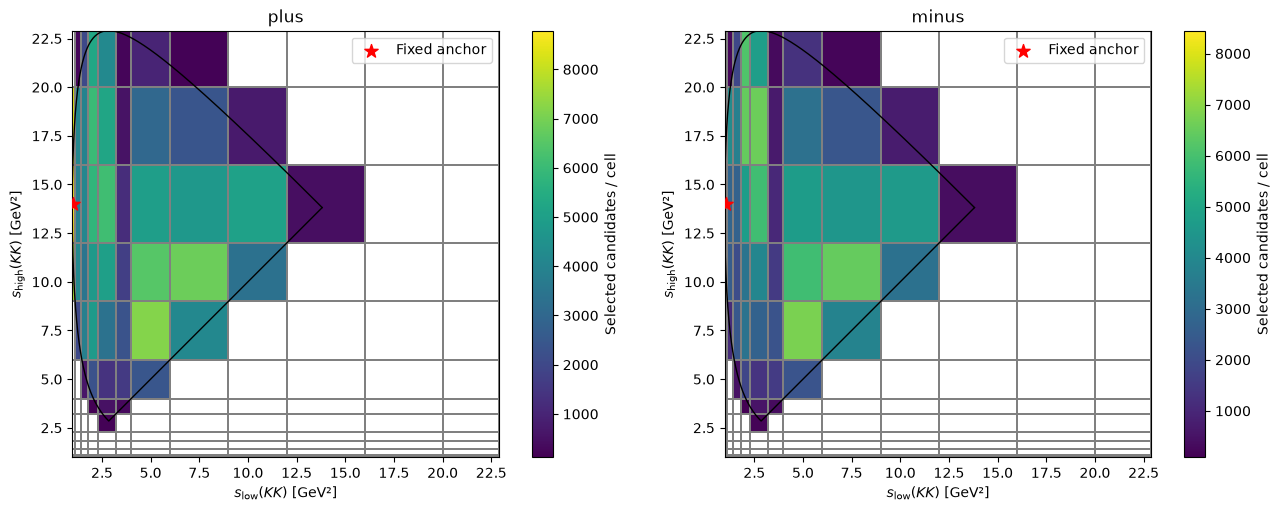

In [7]:
_qmi2d_edges = np.asarray(QMI2D_EDGES_GEV2)
_qmi2d_centers = 0.5 * (_qmi2d_edges[:-1] + _qmi2d_edges[1:])
_qmi2d_shape = (len(_qmi2d_centers),) * 2

# Relabel daughters as (K-, K+, K+) ONLY for the boundary helper.
# All masses are equal, so DAUGHTER_MASSES also applies to this permutation.
_mask_options = dict(mother_mass=M_B_GEV, masses=DAUGHTER_MASSES, folded=True)
_mask_257 = np.asarray(physical_bin_mask(
    QMI2D_EDGES_GEV2, QMI2D_EDGES_GEV2, samples_per_bin=257, **_mask_options,
))
_mask_1025 = np.asarray(physical_bin_mask(
    QMI2D_EDGES_GEV2, QMI2D_EDGES_GEV2, samples_per_bin=1025, **_mask_options,
))
assert np.array_equal(_mask_257, _mask_1025), 'Refine the physical-mask sampling.'


def _outside_charm_windows(s):
    mass = np.sqrt(np.maximum(s, 0.0))
    return ((np.abs(mass - D0_MASS_GEV) > D0_VETO_HALF_WIDTH_GEV)
            & (np.abs(mass - JPSI_MASS_GEV) > JPSI_VETO_HALF_WIDTH_GEV))


def _physical_cell_point(i, j):
    """Physical accepted point nearest to the bin centre (scaled distance).

    Search x and clip y to exact kinematic limits, the folded half-plane,
    the bin, and accepted intervals outside the two charm windows.
    """
    x0, x1 = _qmi2d_edges[i:i + 2]
    y0, y1 = _qmi2d_edges[j:j + 2]
    xc, yc = _qmi2d_centers[i], _qmi2d_centers[j]
    xs = np.unique(np.r_[np.linspace(x0, x1, 1027)[1:-1], xc])
    lower, upper = dalitz_s13_limits(
        jnp.asarray(xs), mother_mass=M_B_GEV, masses=DAUGHTER_MASSES,
    )
    lower = np.maximum.reduce([np.asarray(lower), xs, np.full_like(xs, y0)])
    upper = np.minimum(np.asarray(upper), y1)
    veto_edges = sorted([y0, y1] + [edge for mass, width in (
        (D0_MASS_GEV, D0_VETO_HALF_WIDTH_GEV),
        (JPSI_MASS_GEV, JPSI_VETO_HALF_WIDTH_GEV),
    ) for edge in ((mass-width)**2, (mass+width)**2) if y0 < edge < y1])
    candidates = []
    for a, b in zip(veto_edges[:-1], veto_edges[1:]):
        if not _outside_charm_windows(0.5 * (a + b)):
            continue
        lo, hi = np.maximum(lower, a), np.minimum(upper, b)
        valid = (hi - lo > 1e-9) & _outside_charm_windows(xs)
        if np.any(valid):
            eps = np.minimum(1e-7, 0.1 * (hi[valid] - lo[valid]))
            ys = np.clip(yc, lo[valid] + eps, hi[valid] - eps)
            points = np.column_stack((xs[valid], ys))
            candidates.extend(points)
    if not candidates:
        return None
    points = np.asarray(candidates)
    distance = ((points[:, 0]-xc)/(x1-x0))**2 + ((points[:, 1]-yc)/(y1-y0))**2
    return points[np.argmin(distance)]


QMI2D_SEED_POINTS = {}
for i, j in np.argwhere(_mask_1025 & np.triu(np.ones(_qmi2d_shape, dtype=bool))):
    point = _physical_cell_point(int(i), int(j))
    if point is not None:
        QMI2D_SEED_POINTS[(int(i), int(j))] = point
QMI2D_ACTIVE_MASK = tuple(tuple((i, j) in QMI2D_SEED_POINTS
                               for j in range(_qmi2d_shape[1]))
                         for i in range(_qmi2d_shape[0]))
qmi2d_active = np.asarray(QMI2D_ACTIVE_MASK)
assert qmi2d_active[QMI2D_ANCHOR_CELL], 'Choose a physical accepted anchor cell.'

qmi2d_occupancy = {}
for charge, sample in samples.items():
    low = np.minimum(sample.s13, sample.s23)
    high = np.maximum(sample.s13, sample.s23)
    qmi2d_occupancy[charge] = np.histogram2d(
        low, high, bins=(_qmi2d_edges, _qmi2d_edges),
    )[0].astype(int)
    print(charge, 'candidates in inactive cells:',
          int(qmi2d_occupancy[charge][~qmi2d_active].sum()))

qmi2d_bin_table = pd.DataFrame([
    dict(i=i, j=j,
         s_low_min=_qmi2d_edges[i], s_low_max=_qmi2d_edges[i+1],
         s_high_min=_qmi2d_edges[j], s_high_max=_qmi2d_edges[j+1],
         n_plus=qmi2d_occupancy['plus'][i, j],
         n_minus=qmi2d_occupancy['minus'][i, j],
         anchor=(i, j) == QMI2D_ANCHOR_CELL)
    for i, j in QMI2D_SEED_POINTS
])
qmi2d_bin_table['review_occupancy'] = (
    qmi2d_bin_table[['n_plus', 'n_minus']].min(axis=1) < QMI2D_MIN_EVENTS_REVIEW
)
print('Active cells:', int(qmi2d_active.sum()))
print('Free field parameters:', 2 * (int(qmi2d_active.sum()) - 1))
display(qmi2d_bin_table)

# Exact folded boundary, overlaid to distinguish a bin from its physical part.
_boundary_x = np.linspace(_qmi2d_edges[0] + 1e-8, _qmi2d_edges[-1] - 1e-8, 2000)
_boundary_lo, _boundary_hi = dalitz_s13_limits(
    jnp.asarray(_boundary_x), mother_mass=M_B_GEV, masses=DAUGHTER_MASSES,
)
_boundary_lo = np.maximum(np.asarray(_boundary_lo), _boundary_x)
_boundary_hi = np.asarray(_boundary_hi)
_boundary_valid = _boundary_hi >= _boundary_lo

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, charge in zip(axes, ('plus', 'minus')):
    mesh = ax.pcolormesh(
        _qmi2d_edges, _qmi2d_edges,
        np.ma.array(qmi2d_occupancy[charge], mask=~qmi2d_active).T,
        shading='flat', edgecolors='grey', linewidth=0.3,
    )
    ax.set(xlabel=r'$s_\mathrm{low}(KK)$ [GeV²]',
           ylabel=r'$s_\mathrm{high}(KK)$ [GeV²]', title=charge, aspect='equal')
    ax.plot(_boundary_x[_boundary_valid], _boundary_lo[_boundary_valid], 'k-', lw=1)
    ax.plot(_boundary_x[_boundary_valid], _boundary_hi[_boundary_valid], 'k-', lw=1)
    ax.scatter(*QMI2D_SEED_POINTS[QMI2D_ANCHOR_CELL], marker='*',
               s=100, color='red', label='Fixed anchor', zorder=4)
    ax.legend()
    fig.colorbar(mesh, ax=ax, label='Selected candidates / cell')
plt.show()


## Modelo coerente e semente isóbara do QMI2D

In [8]:
# The isobar S-wave this notebook replaces with QMI2D (see the intro markdown
# above): kept here only to seed the QMI2D cells below with a physically
# motivated starting shape, not part of this notebook's fit model. Values are
# the same BaBar-derived starting points 12_b2kkk_cpvfit.ipynb uses for these
# components. (These internal labels are not renamed to match `particle`
# below -- they never feed a Resonance mass/width lookup, only this seed.)
_OLD_SWAVE_STARTS = {
    'f0_980': dict(rho=5.20, phase=0.48),
    'rescattering2': dict(rho=0.10, phase=0.00),
    'f0_1500': dict(rho=8.20, phase=1.29),
    'f0_1710': dict(rho=1.22, phase=-0.59),
    'NR': dict(rho=13.2, phase=0.00),
}
_OLD_NR_ALPHA = 0.152


def polar_to_xy(rho, phase):
    return float(rho * np.cos(phase)), float(rho * np.sin(phase))


@dataclass(frozen=True)
class BaBarExponentialNR:
    alpha: object

    def __call__(self, data):
        alpha = jnp.asarray(self.alpha)
        return (
            jnp.exp(-alpha * jnp.asarray(data['s13']))
            + jnp.exp(-alpha * jnp.asarray(data['s23']))
        ) / jnp.sqrt(2.0)


def _old_swave_reference_model():
    coefficient = {
        name: RealImag(*polar_to_xy(config['rho'], config['phase']))
        for name, config in _OLD_SWAVE_STARTS.items()
    }
    return DecayModel(
        DecayChannel('B+', ('K+', 'K+', 'K-')),
        [
            Resonance(
                'f0_980',
                (0, 2),
                coefficient['f0_980'],
                lineshape=BaBarFlatte(),
                mass=0.965,
                width=0.0,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rescattering2',
                (0, 2),
                coefficient['rescattering2'],
                lineshape=Rescattering2(),
                mass=1.47,
                width=0.0,
                spin=0,
                resonance_radius=0.0,
                parent_radius=0.0,
            ),
            Resonance(
                'f0_1500',
                (0, 2),
                coefficient['f0_1500'],
                mass=1.522,
                width=0.108,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'f0_1710',
                (0, 2),
                coefficient['f0_1710'],
                mass=1.715,
                width=0.125,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            DalitzAmplitude(
                'NR',
                dynamics=BaBarExponentialNR(_OLD_NR_ALPHA),
                coefficient=coefficient['NR'],
            ),
        ],
        normalize_components=False,
    )


@dataclass(frozen=True)
class OppositeSignQMI2D:
    """Preserve ROOT/channel ordering; fold the two opposite-sign invariants.

    A dataclass keeps the nested Parameter.dynamics nodes visible to the
    public DecayModel parameter collector and recursive value resolver.
    """
    field: QMI2D

    def __call__(self, data):
        return self.field({'s12': data['s13'], 's13': data['s23']})


_seed_cells = list(QMI2D_SEED_POINTS)
_seed_xy = np.asarray([QMI2D_SEED_POINTS[cell] for cell in _seed_cells])
_seed_data = {
    's13': jnp.asarray(_seed_xy[:, 0]),
    's23': jnp.asarray(_seed_xy[:, 1]),
    's12': jnp.asarray(M_B_GEV**2 + 3.0*M_K_GEV**2 - _seed_xy.sum(axis=1)),
}
_qmi_seed_amplitude = np.asarray(_old_swave_reference_model().amplitude(_seed_data))
_anchor_index = _seed_cells.index(QMI2D_ANCHOR_CELL)
_qmi_seed_coefficient = complex(_qmi_seed_amplitude[_anchor_index])
assert np.isfinite(_qmi_seed_amplitude).all() and abs(_qmi_seed_coefficient) > 1e-10
_qmi_seed_relative = _qmi_seed_amplitude / _qmi_seed_coefficient
QMI2D_SEED_MAGNITUDES = np.zeros(_qmi2d_shape)
QMI2D_SEED_PHASES = np.zeros(_qmi2d_shape)
_raw_phases = {}
for cell, value in zip(_seed_cells, _qmi_seed_relative):
    QMI2D_SEED_MAGNITUDES[cell] = abs(value)
    _raw_phases[cell] = np.angle(value)

# Unwrap along an active-cell spanning tree, starting at the anchor.
# Inspect the resulting map; a 2D phase field need not have a globally
# smooth branch around zeros. This is an initial seed, not a phase constraint.
_pending = [QMI2D_ANCHOR_CELL]
_seen = {QMI2D_ANCHOR_CELL}
while _pending:
    i, j = _pending.pop(0)
    for cell in ((i-1, j), (i+1, j), (i, j-1), (i, j+1)):
        if cell in _raw_phases and cell not in _seen:
            delta = np.angle(np.exp(1j * (_raw_phases[cell] - QMI2D_SEED_PHASES[i, j])))
            QMI2D_SEED_PHASES[cell] = QMI2D_SEED_PHASES[i, j] + delta
            _seen.add(cell)
            _pending.append(cell)
assert len(_seen) == len(_seed_cells), 'Unwrap disconnected active regions explicitly.'
QMI2D_SEED_MAGNITUDES[QMI2D_ANCHOR_CELL] = 1.0
QMI2D_SEED_PHASES[QMI2D_ANCHOR_CELL] = 0.0
print('QMI2D coefficient seed (no extra symmetrization factor):', _qmi_seed_coefficient)


COEFFICIENT_STARTS = {
    # BaBar baseline starting values for the non-S-wave components, plus the
    # QMI2D field's seeded starting point. f0_980, rescattering2, f0_1500,
    # f0_1710 and NR from 12_b2kkk_cpvfit.ipynb are replaced by QMI2D;
    # chi(c0)(1P) stays a separate component (see the intro markdown above).
    # Every real resonance is keyed by its exact `particle`-recognized name
    # (see pdg_mass_width() above), so mass/width sourcing and this
    # coefficient dict use one consistent identifier per component.
    'phi(1020)': dict(rho=1.00, phase=0.0),
    'rho(770)0': dict(rho=0.10, phase=0.00),
    'rho(1450)0': dict(rho=0.10, phase=0.00),
    'rho(1700)0': dict(rho=0.10, phase=0.00),
    "f(2)'(1525)": dict(rho=0.10, phase=0.00),
    'phi(1680)': dict(rho=0.10, phase=0.00),
    'chi(c0)(1P)': dict(rho=0.437, phase=-1.02),
    'QMI2D': dict(
        rho=float(abs(_qmi_seed_coefficient)),
        phase=float(np.angle(_qmi_seed_coefficient)),
    ),
}


def make_cp_coefficients():
    result = {}

    for name, config in COEFFICIENT_STARTS.items():
        x0, y0 = polar_to_xy(config['rho'], config['phase'])
        is_reference = name == 'phi(1020)'

        # phi(1020) is the global reference: x, y fixed to remove the overall
        # amplitude scale/phase, dy fixed, only dx free (below). Every other
        # component -- including QMI2D and chi(c0)(1P) -- is a fully free
        # CPRealImag; for QMI2D this is the "global CPV" applied uniformly
        # to every cell (the cells themselves carry no separate CP
        # parameters).
        x = Parameter.coefficient(
            f'{name}.x',
            x0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )
        y = Parameter.coefficient(
            f'{name}.y',
            y0,
            owner=name,
            fixed=is_reference,
            step=0.01,
        )

        # Reference (phi(1020)) convention: dx free, dy fixed.
        dx = Parameter.coefficient(
            f'{name}.dx',
            0.0,
            owner=name,
            fixed=False,
            step=0.005,
        )
        dy = Parameter.coefficient(
            f'{name}.dy',
            0.0,
            owner=name,
            fixed=is_reference,
            step=0.005,
        )

        result[name] = CPRealImag(x, y, dx, dy)

    return result


def build_models(*, normalization_options=None):
    shared = make_cp_coefficients()

    # rho(1450)0/rho(1700)0 mass and width as fittable dynamics parameters
    # (shared across both charges, like nr_alpha in 12_b2kkk_cpvfit.ipynb)
    # rather than plain floats, so a GaussianConstraint can pin them to their
    # PDG-2026 central values (pdg_mass_width() above).
    # FREE_RHO_1450_1700_MASS_WIDTH toggles fixed vs. floating; the Gaussian
    # penalty around the PDG value applies either way (see build_session()).
    rho0_1450_mass = Parameter.dynamics(
        'rho(1450)0.mass',
        RHO0_1450_PDG['mass'],
        owner='rho(1450)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(1.30, 1.60),
        step=0.005,
    )
    rho0_1450_width = Parameter.dynamics(
        'rho(1450)0.width',
        RHO0_1450_PDG['width'],
        owner='rho(1450)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(0.10, 0.70),
        step=0.010,
    )
    rho0_1700_mass = Parameter.dynamics(
        'rho(1700)0.mass',
        RHO0_1700_PDG['mass'],
        owner='rho(1700)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(1.55, 1.90),
        step=0.005,
    )
    rho0_1700_width = Parameter.dynamics(
        'rho(1700)0.width',
        RHO0_1700_PDG['width'],
        owner='rho(1700)0',
        fixed=not FREE_RHO_1450_1700_MASS_WIDTH,
        bounds=(0.05, 0.50),
        step=0.010,
    )
    # phi(1020)/chi(c0)(1P) mass and width, same fixed-with-optional-float
    # convention as rho(1450)0/rho(1700)0 above (FREE_PHI1020_MASS_WIDTH /
    # FREE_CHIC0_MASS_WIDTH).
    phi1020_mass = Parameter.dynamics(
        'phi(1020).mass',
        PHI1020_PDG['mass'],
        owner='phi(1020)',
        fixed=not FREE_PHI1020_MASS_WIDTH,
        bounds=(0.99, 1.05),
        step=0.0005,
    )
    phi1020_width = Parameter.dynamics(
        'phi(1020).width',
        PHI1020_PDG['width'],
        owner='phi(1020)',
        fixed=not FREE_PHI1020_MASS_WIDTH,
        bounds=(0.001, 0.010),
        step=0.0002,
    )
    chic0_mass = Parameter.dynamics(
        'chi(c0)(1P).mass',
        CHIC0_PDG['mass'],
        owner='chi(c0)(1P)',
        fixed=not FREE_CHIC0_MASS_WIDTH,
        bounds=(3.38, 3.45),
        step=0.0005,
    )
    chic0_width = Parameter.dynamics(
        'chi(c0)(1P).width',
        CHIC0_PDG['width'],
        owner='chi(c0)(1P)',
        fixed=not FREE_CHIC0_MASS_WIDTH,
        bounds=(0.001, 0.030),
        step=0.0005,
    )

    mass_width_constraints = (
        GaussianConstraint(rho0_1450_mass, mean=RHO0_1450_PDG['mass'], sigma=RHO0_1450_PDG['mass_sigma']),
        GaussianConstraint(rho0_1450_width, mean=RHO0_1450_PDG['width'], sigma=RHO0_1450_PDG['width_sigma']),
        GaussianConstraint(rho0_1700_mass, mean=RHO0_1700_PDG['mass'], sigma=RHO0_1700_PDG['mass_sigma']),
        GaussianConstraint(rho0_1700_width, mean=RHO0_1700_PDG['width'], sigma=RHO0_1700_PDG['width_sigma']),
        GaussianConstraint(phi1020_mass, mean=PHI1020_PDG['mass'], sigma=PHI1020_PDG['mass_sigma']),
        GaussianConstraint(phi1020_width, mean=PHI1020_PDG['width'], sigma=PHI1020_PDG['width_sigma']),
        GaussianConstraint(chic0_mass, mean=CHIC0_PDG['mass'], sigma=CHIC0_PDG['mass_sigma']),
        GaussianConstraint(chic0_width, mean=CHIC0_PDG['width'], sigma=CHIC0_PDG['width_sigma']),
    )

    def node_grid(values, label):
        return tuple(tuple(
            Parameter.dynamics(
                f'QMI2D.{label}_{i:02d}_{j:02d}', float(values[i, j]),
                owner='QMI2D', fixed=((i, j) == QMI2D_ANCHOR_CELL),
                bounds=(0.0, None) if label == 'mag' else None,
                step=max(0.01, 0.02 * float(values[i, j])) if label == 'mag' else 0.02,
            ) if qmi2d_active[i, j] else 0.0
            for j in range(_qmi2d_shape[1])) for i in range(_qmi2d_shape[0]))

    qmi2d_dynamics = OppositeSignQMI2D(QMI2D(
        s12_edges=QMI2D_EDGES_GEV2, s13_edges=QMI2D_EDGES_GEV2,
        magnitudes=node_grid(QMI2D_SEED_MAGNITUDES, 'mag'),
        phases=node_grid(QMI2D_SEED_PHASES, 'phase'),
        active_mask=QMI2D_ACTIVE_MASK, folded=True,
        interpolation=QMI2D_INTERPOLATION,
    ))

    def components(charge):
        coefficient = {
            name: cp_coefficient.for_charge(charge)
            for name, cp_coefficient in shared.items()
        }

        return [
            Resonance(
                'phi(1020)',
                (0, 2),
                coefficient['phi(1020)'],
                mass=phi1020_mass,
                width=phi1020_width,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho(770)0',
                (0, 2),
                coefficient['rho(770)0'],
                mass=RHO0_770_PDG['mass'],
                width=RHO0_770_PDG['width'],
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho(1450)0',
                (0, 2),
                coefficient['rho(1450)0'],
                mass=rho0_1450_mass,
                width=rho0_1450_width,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'rho(1700)0',
                (0, 2),
                coefficient['rho(1700)0'],
                mass=rho0_1700_mass,
                width=rho0_1700_width,
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            DalitzAmplitude(
                'QMI2D', qmi2d_dynamics, coefficient['QMI2D'],
                normalize_component=False,
            ),
            Resonance(
                "f(2)'(1525)",
                (0, 2),
                coefficient["f(2)'(1525)"],
                mass=F2P_1525_PDG['mass'],
                width=F2P_1525_PDG['width'],
                spin=2,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'phi(1680)',
                (0, 2),
                coefficient['phi(1680)'],
                mass=PHI1680_PDG['mass'],
                width=PHI1680_PDG['width'],
                spin=1,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
            Resonance(
                'chi(c0)(1P)',
                (0, 2),
                coefficient['chi(c0)(1P)'],
                mass=chic0_mass,
                width=chic0_width,
                spin=0,
                resonance_radius=4.0,
                parent_radius=4.0,
            ),
        ]

    # Preserve the active deterministic normalization of the input notebook.
    # The optional override is useful for a small numerical smoke test.
    if normalization_options is None:
        normalization_options = dict(
            normalization_method="gauss-legendre",
            normalization_bin_width=0.005,
            normalization_narrow_width=0.020,
            normalization_narrow_window=5.0,
            normalization_binning_factor=20.0,
            normalization_chunk_size=25_000,
        )

    plus = DecayModel(
        DecayChannel('B+', ('K+', 'K+', 'K-')),
        components(+1),
        normalize_components=False,
        **normalization_options,
    )

    minus = DecayModel(
        DecayChannel('B-', ('K-', 'K-', 'K+')),
        components(-1),
        normalize_components=False,
        **normalization_options,
    )

    return plus, minus, shared, mass_width_constraints


plus_model, minus_model, shared_coefficients, mass_width_constraints = build_models()

print("normalization_method =", plus_model.normalization_method)
print("B+ normalization points =", plus_model.normalization_sample.size)
print("B- normalization points =", minus_model.normalization_sample.size)


QMI2D coefficient seed (no extra symmetrization factor): (-1.1853794307714836+16.091396060460887j)
normalization_method = gauss-legendre
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=1.019460 GeV, Gamma=4.249 MeV; m13: m0=3.415500 GeV, Gamma=12.400 MeV; m23: m0=1.019460 GeV, Gamma=4.249 MeV; m23: m0=3.415500 GeV, Gamma=12.400 MeV); using adaptive Gauss-Legendre normalization.
B+ normalization points = 749331
INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=1.019460 GeV, Gamma=4.249 MeV; m13: m0=3.415500 GeV, Gamma=12.400 MeV; m23: m0=1.019460 GeV, Gamma=4.249 MeV; m23: m0=3.415500 GeV, Gamma=12.400 MeV); using adaptive Gauss-Legendre normalization.
B- normalization points = 749331


### Massas e larguras das ressonâncias

Tabela dos valores usados, parâmetros fixos/livres e vínculos Gaussianos.
O `DalitzAmplitude("QMI2D", ...)` não possui massa ou largura e não entra nesta tabela.


In [9]:
def _resolve_scalar(value):
    return float(value.value) if isinstance(value, Parameter) else float(value)


def _is_fixed(value):
    return bool(value.fixed) if isinstance(value, Parameter) else True


_constraint_by_parameter = {
    constraint.parameter.name: constraint for constraint in mass_width_constraints
}


def _constraint_sigma(value):
    if not isinstance(value, Parameter):
        return np.nan
    constraint = _constraint_by_parameter.get(value.name)
    return float(constraint.sigma) if constraint is not None else np.nan


mass_width_rows = [
    dict(
        component=component.name,
        mass_GeV=_resolve_scalar(component.mass),
        mass_fixed=_is_fixed(component.mass),
        mass_constraint_sigma_GeV=_constraint_sigma(component.mass),
        width_GeV=_resolve_scalar(component.width),
        width_fixed=_is_fixed(component.width),
        width_constraint_sigma_GeV=_constraint_sigma(component.width),
    )
    for component in plus_model.components
    if isinstance(component, Resonance) and component.name != 'QMI2D'
]

mass_width_table = pd.DataFrame(mass_width_rows)
display(mass_width_table)


,component,mass_GeV,mass_fixed,mass_constraint_sigma_GeV,width_GeV,width_fixed,width_constraint_sigma_GeV
0,phi(1020),1.01946,True,0.000016,0.004249,True,0.000013
1,rho(770)0,0.77526,True,NaN,0.147400,True,NaN
2,rho(1450)0,1.46500,True,0.025000,0.400000,True,0.060000
3,rho(1700)0,1.72000,True,0.020000,0.250000,True,0.100000
4,f(2)'(1525),1.51730,True,NaN,0.072000,True,NaN
5,phi(1680),1.68000,True,NaN,0.150000,True,NaN
6,chi(c0)(1P),3.41550,True,0.000190,0.012400,True,0.000270


### Componentes isóbaros explícitos

`phi(1680)` permanece como spin 1 no par `(0,2)`, com os valores da tabela PDG
acima. As antigas contribuições `f0_980`, `rescattering2`, `f0_1500`, `f0_1710`
e `NR` entram apenas na semente do QMI2D, não como componentes extras no ajuste.


### CP convention for charmonium

\(\chi_{c0}\) is a fully free `CPRealImag` component (\(x,y,dx,dy\) all float), the same as every other non-reference charmless amplitude in this model.

`phi(1020)` is the global CP reference: its \(x,y\) and \(dy\) are fixed, only \(dx\) floats, removing the overall amplitude scale/phase of the whole coherent sum.

### QMI2D e vetos de charm

O campo compartilhado tem um coeficiente global `CPRealImag`, com uma célula
ancorada em (magnitude, fase) = (1, 0). `chi(c0)(1P)` continua separada.

A `CompositeVeto` made from two `MassWindowVeto` objects removes

\[
|m(K^+K^-)-m_{D^0}| \le 60\,\mathrm{MeV}
\]

for both opposite-sign pairings, and a second `CompositeVeto` removes

\[
|m(K^+K^-)-m_{J/\psi}| \le 30\,\mathrm{MeV}
\]

(both half-widths configurable via `D0_VETO_HALF_WIDTH_GEV` /
`JPSI_VETO_HALF_WIDTH_GEV`). The two are combined into one `CHARM_VETO`. The
model does not fit an explicit `Jpsi_1S` component -- that mass region is
excised by the veto instead. The same combined veto is applied to the
selected data and to the fit session, so signal normalization, combinatorial
background and fit projections all use the same accepted Dalitz region. The
QMI2D interpolates through veto windows, but those regions are not measured.
The surrounding cells and interpolation determine the extrapolation; a smooth
map there does not imply a phase or magnitude measurement inside the veto.


## Simultaneous fit session

In [10]:

def build_session():
    if SEPARATE_BKG_BY_CHARGE:
        plus_background, _ = build_background_map(bkg_sqdp['plus'])
        minus_background, _ = build_background_map(bkg_sqdp['minus'])
    else:
        common_background, _ = build_background_map(bkg_sqdp['all'])
        plus_background = common_background
        minus_background = common_background

    # N_signal, A_yield and N_combinatorial are known (fixed) rather than
    # fit here -- only the amplitude parameters float.
    signal_yield = YieldAsymmetry(
        Parameter(
            'n_signal',
            SIGNAL_YIELD,
            fixed=True,
        ),
        Parameter(
            'a_cp_yield',
            YIELD_ASYMMETRY,
            fixed=True,
        ),
    )

    fit_session = CPFitSession(
        plus_model,
        minus_model,
        samples['plus'],
        samples['minus'],
        extended=True,
        signal_yield=signal_yield,
    )

    if USE_EFFICIENCY:
        plus_efficiency, _ = build_efficiency_map(efficiency_mc['plus'])
        minus_efficiency, _ = build_efficiency_map(efficiency_mc['minus'])
        fit_session = fit_session.with_efficiency(
            plus_efficiency,
            minus_efficiency,
        )

    fit_session = fit_session.with_veto(CHARM_VETO)

    fit_session = fit_session.with_background(
        'combinatorial',
        plus_background,
        minus_shape=minus_background,
        yield_=Parameter(
            'n_combinatorial',
            BACKGROUND_YIELD,
            fixed=True,
        ),
    )

    # rho(1450)0/rho(1700)0, phi(1020) and chi(c0)(1P) mass/width all stay
    # Gaussian-constrained to their PDG values whether they are fixed or
    # floated (see FREE_RHO_1450_1700_MASS_WIDTH / FREE_PHI1020_MASS_WIDTH /
    # FREE_CHIC0_MASS_WIDTH above).
    for constraint in mass_width_constraints:
        fit_session = fit_session.with_constraint(constraint)

    return fit_session


session = build_session()

for parameter in session.parameters:
    print(
        f"{parameter.name:24s} "
        f"value={parameter.value: .6g} fixed={parameter.fixed}"
    )

print('Free parameters:', sum(not p.fixed for p in session.parameters))


phi(1020).x              value= 1 fixed=True
phi(1020).y              value= 0 fixed=True
phi(1020).dx             value= 0 fixed=False
phi(1020).dy             value= 0 fixed=True
phi(1020).mass           value= 1.01946 fixed=True
phi(1020).width          value= 0.004249 fixed=True
rho(770)0.x              value= 0.1 fixed=False
rho(770)0.y              value= 0 fixed=False
rho(770)0.dx             value= 0 fixed=False
rho(770)0.dy             value= 0 fixed=False
rho(1450)0.x             value= 0.1 fixed=False
rho(1450)0.y             value= 0 fixed=False
rho(1450)0.dx            value= 0 fixed=False
rho(1450)0.dy            value= 0 fixed=False
rho(1450)0.mass          value= 1.465 fixed=True
rho(1450)0.width         value= 0.4 fixed=True
rho(1700)0.x             value= 0.1 fixed=False
rho(1700)0.y             value= 0 fixed=False
rho(1700)0.dx            value= 0 fixed=False
rho(1700)0.dy            value= 0 fixed=False
rho(1700)0.mass          value= 1.72 fixed=True
rho(1700)0.wid

## Prefit and postfit helpers

In [11]:
def plot_all_diagnostics(fit_result, title_prefix, seed):
    """Folded s_low/s_high projections via `session.plot_projection`
    (data, per-component curves, total fit and pulls) -- the one postfit
    visual `CPFitSession` already implements as a single call, for both
    charges and with a shared-x-axis pull panel included.

    The quantitative 2D diagnostics (plain Dalitz, Square-Dalitz) and the
    unbinned PPD test are *not* reimplemented here a second time: they live
    in the "Goodness of fit" section below via `goodness_of_fit_chi2`/
    `plot_pulls`/`point_to_point_dissimilarity`, which is the actual
    session-level API for them. Earlier revisions of this notebook hand-rolled
    all of this (custom 1D mass-unit projections, custom Square-Dalitz 1D
    projections reading the ROOT files' own mPrime/thPrime branches, and
    custom 2D data/model/pull triptychs); those pieces are dropped rather
    than kept as one-off duplicates of what the fitter now provides directly.
    """
    for fold_side in ('low', 'high'):
        session.plot_projection(
            fit_result, 's13', partner_variable='s23',
            folded=True, fold_side=fold_side,
            bins=PROJECTION_BINS, projection_size=PROJECTION_SIZE,
            projection_seed=seed, show_pulls=True,
        )
        plt.show()

    # Zoomed s_low (< 4 GeV^2): the same projection restricted to where the
    # low-mass structure (threshold cusp, f0(1500)/f0(1710) region) sits,
    # since the full s13 in [~1, ~23] GeV^2 range above compresses it.
    print(f"{title_prefix}: s_low zoom below 4 GeV^2")
    session.plot_projection(
        fit_result, 's13', partner_variable='s23',
        folded=True, fold_side='low', range=(QMI2D_THRESHOLD_GEV**2, 4.0),
        bins=PROJECTION_BINS, projection_size=PROJECTION_SIZE,
        projection_seed=seed, show_pulls=True,
    )
    plt.show()


## Ajuste com Minuit

`FIT_STRATEGY` controla a estratégia e `FIT_HESSIAN="jax"` fornece derivadas
segundas automáticas, incluindo HESSE no MIGRAD. A primeira chamada compila o
programa JAX. O número de parâmetros depende das células ativas e é exibido
acima; mantenha `hesse=True` para obter a covariância final.

Compare múltiplos pontos iniciais e verifique EDM, limites e correlações.
O campo 2D pode competir com os isóbaros explícitos; convergência numérica
sozinha não garante uma decomposição física única.


In [12]:

if FIT_NSTARTS == 1:
    result = session.fit(
        simplex=False,
        strategy=FIT_STRATEGY,
        hessian=FIT_HESSIAN,
        hesse=True,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    scan_results = (result,)
else:
    multistart = session.fit_multistart(
        n_starts=FIT_NSTARTS,
        seed=FIT_SEED,
        include_default=True,
        simplex=False,
        strategy=FIT_STRATEGY,
        hessian=FIT_HESSIAN,
        tolerance=FIT_TOLERANCE,
        verbose=FIT_VERBOSE,
    )
    result = multistart.best
    scan_results = multistart.results

fit_report = session.report(
    result,
    include_fit_fractions=False,
    include_correlation=True,
)


[Minimizer] single fit with 129 free parameters (method=minuit, simplex=False, strategy=1, hesse=True, hessian=jax, ncall=None, tolerance=0.0001)
[Minimizer] MIGRAD 1 started
I MnSeedGenerator Computing seed using analytical (external) gradients and Hessian calculator
I NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
I NegativeG2LineSearch Done after 37.9218 s
I MnSeedGenerator Initial seeding state  
  Minimum value : -1971345.681
  Edm           : 134577.1386
  Internal parameters:	[                0              0.1                0                0                0              0.1                0                0                0              0.1....                 0]	
  Internal gradient  :	[       5569.14547     -7883.112757     -2381.578044     -568.8121122      3046.654311     -3575.138936     -6229.127329     -3012.933753     -2015.905563     -9067.470216....         -579.6702]	
  Internal covariance matrix:
[[   1.241479e-05     

## Yield asymmetry

In [13]:
postfit_yield_values = session.result_values(result)

expected_total = float(session.base_objective.expected_events(postfit_yield_values))
n_signal_total = float(session.signal_yield.total.resolve(postfit_yield_values))
a_cp_yield = float(session.signal_yield.asymmetry.resolve(postfit_yield_values))
n_signal_plus = float(session.signal_yield.plus(postfit_yield_values))
n_signal_minus = float(session.signal_yield.minus(postfit_yield_values))

print(f"expected total events (signal + background): {expected_total:.2f}")
print(f"N_signal (total)  = {n_signal_total:.2f}")
print(f"A_yield           = {a_cp_yield:.4f}")
print(f"N_signal(B+)      = {n_signal_plus:.2f}")
print(f"N_signal(B-)      = {n_signal_minus:.2f}")

expected total events (signal + background): 335370.00
N_signal (total)  = 323514.00
A_yield           = -0.0370
N_signal(B+)      = 167742.01
N_signal(B-)      = 155771.99


## Fit fractions

Central values plus delta-method standard errors (exact `jax.jacrev` Jacobian of `PreparedAmplitudeCache.fit_fractions` through the postfit covariance -- see `docs/fitting.md` "Fit fraction errors (delta method)" for the full derivation, the joint-covariance treatment of `FF_mean`, and a documented pitfall in propagating a Minuit covariance by shape instead of by parameter name).

In [14]:
fit_fractions = session.print_fit_fractions(
    result,
    acceptance_weighted=USE_EFFICIENCY,
    include_interference=False,
    precision=4,
)

# Delta-method standard errors (exact autodiff Jacobian x postfit covariance,
# see docs/fitting.md "Fit fraction errors"). fit_fraction_errors propagates
# the *joint* B+/B- covariance in one Jacobian rather than two independent
# ones, since almost every fit parameter here (every QMI2D cell, every
# CPRealImag coefficient) is shared between the two charges -- that shared
# covariance is what makes 'mean' below more than a naive quadrature sum.
fit_fraction_errors = session.fit_fraction_errors(
    result, acceptance_weighted=USE_EFFICIENCY,
)

plus_ff = fit_fractions['plus']
minus_ff = fit_fractions['minus']

component_names = [
    name for name in plus_ff
    if name in minus_ff
]

ff_table = pd.DataFrame({
    'component': component_names,
    'FF_plus': [float(plus_ff[name]) for name in component_names],
    'sigma(FF_plus)': [fit_fraction_errors['plus'][name] for name in component_names],
    'FF_minus': [float(minus_ff[name]) for name in component_names],
    'sigma(FF_minus)': [fit_fraction_errors['minus'][name] for name in component_names],
})

ff_table['FF_mean'] = 0.5 * (
    ff_table['FF_plus'] + ff_table['FF_minus']
)
ff_table['sigma(FF_mean)'] = [
    fit_fraction_errors['mean'][name] for name in component_names
]

display(ff_table)

B+ fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi(1020)                         14.1584
rho(770)0                          8.9499
rho(1450)0                         5.8626
rho(1700)0                         1.8640
QMI2D                             86.8234
f(2)'(1525)                        2.1380
phi(1680)                          0.9063
chi(c0)(1P)                        1.5336
sum                              122.2363

B- fit fractions
Fit fractions (acceptance-weighted)
component                    fraction [%]
phi(1020)                         15.5093
rho(770)0                          6.0629
rho(1450)0                         1.0991
rho(1700)0                        11.4607
QMI2D                             81.7316
f(2)'(1525)                        3.9938
phi(1680)                          6.2605
chi(c0)(1P)                        1.7227
sum                              127.8407


,component,FF_plus,sigma(FF_plus),FF_minus,sigma(FF_minus),FF_mean,sigma(FF_mean)
0,phi(1020),0.141584,0.000993,0.155093,0.001068,0.148338,0.000759
1,rho(770)0,0.089499,0.005106,0.060629,0.003700,0.075064,0.004180
2,rho(1450)0,0.058626,0.005078,0.010991,0.001943,0.034809,0.003131
3,rho(1700)0,0.018640,0.003602,0.114607,0.008358,0.066624,0.005237
4,QMI2D,0.868234,0.004756,0.817316,0.004537,0.842775,0.004425
5,f(2)'(1525),0.021380,0.001185,0.039938,0.001632,0.030659,0.001316
6,phi(1680),0.009063,0.001975,0.062605,0.005084,0.035834,0.003006
7,chi(c0)(1P),0.015336,0.000420,0.017227,0.000470,0.016282,0.000333


## CP coefficients

In [15]:
def _cp_observables(theta):
    x, y, dx, dy = theta
    c_plus = complex(x + dx, y + dy)
    c_minus = complex(x - dx, y - dy)
    mag_plus = abs(c_plus)
    mag_minus = abs(c_minus)
    phase_plus = np.angle(c_plus)
    phase_minus = np.angle(c_minus)
    denominator = mag_minus**2 + mag_plus**2
    acp = (mag_minus**2 - mag_plus**2) / denominator if denominator > 0.0 else np.nan
    delta_phase = np.angle(np.exp(1j * (phase_minus - phase_plus)))
    return np.asarray([mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase])


def _cp_observable_errors(name, theta):
    parameter_names = [f'{name}.x', f'{name}.y', f'{name}.dx', f'{name}.dy']
    covariance = np.zeros((4, 4), dtype=float)
    fit_covariance = getattr(result, 'covariance', None)

    if fit_covariance is None:
        return np.full(6, np.nan)

    for i, par_i in enumerate(parameter_names):
        for j, par_j in enumerate(parameter_names):
            try:
                covariance[i, j] = float(fit_covariance[par_i, par_j])
            except (KeyError, TypeError):
                # Fixed parameters are absent from the Minuit covariance.
                covariance[i, j] = 0.0

    jacobian = np.empty((6, 4), dtype=float)
    angular_observables = {2, 3, 5}
    for i, value in enumerate(theta):
        step = 1.0e-6 * max(1.0, abs(value))
        theta_hi = theta.copy()
        theta_lo = theta.copy()
        theta_hi[i] += step
        theta_lo[i] -= step
        difference = _cp_observables(theta_hi) - _cp_observables(theta_lo)
        for index in angular_observables:
            difference[index] = np.angle(np.exp(1j * difference[index]))
        jacobian[:, i] = difference / (2.0 * step)

    variances = np.einsum('ai,ij,aj->a', jacobian, covariance, jacobian)
    return np.sqrt(np.maximum(variances, 0.0))


def build_cp_table():
    values = session.result_values(result)
    rows = []

    for name in COEFFICIENT_STARTS:
        x = values[f'{name}.x']
        y = values[f'{name}.y']
        dx = values[f'{name}.dx']
        dy = values[f'{name}.dy']

        theta = np.asarray([x, y, dx, dy], dtype=float)
        observables = _cp_observables(theta)
        uncertainties = _cp_observable_errors(name, theta)
        mag_plus, mag_minus, phase_plus, phase_minus, acp, delta_phase = observables
        err_mag_plus, err_mag_minus, err_phase_plus, err_phase_minus, err_acp, err_delta_phase = uncertainties

        rows.append({
            'component': name,
            '|c+|': mag_plus,
            'sigma(|c+|)': err_mag_plus,
            '|c-|': mag_minus,
            'sigma(|c-|)': err_mag_minus,
            'phi+ [rad]': phase_plus,
            'sigma(phi+) [rad]': err_phase_plus,
            'phi- [rad]': phase_minus,
            'sigma(phi-) [rad]': err_phase_minus,
            'A_CP(coeff)': acp,
            'sigma(A_CP)': err_acp,
            'delta_phi [rad]': delta_phase,
            'sigma(delta_phi) [rad]': err_delta_phase,
        })

    return pd.DataFrame(rows)


cp_table = build_cp_table()
display(cp_table)

,component,|c+|,sigma(|c+|),|c-|,sigma(|c-|),phi+ [rad],sigma(phi+) [rad],phi- [rad],sigma(phi-) [rad],A_CP(coeff),sigma(A_CP),delta_phi [rad],sigma(delta_phi) [rad]
0,phi(1020),0.880905,0.018479,1.119095,0.018479,0.000000,0.000000,0.000000,0.000000,0.234859,0.035422,0.000000,0.000000
1,rho(770)0,2.817441,0.097957,2.799961,0.099971,-2.638107,0.026490,-2.652174,0.026933,-0.006224,0.041578,-0.014067,0.023026
2,rho(1450)0,1.480193,0.069253,0.772186,0.069686,1.509807,0.044444,0.698919,0.084941,-0.572143,0.057033,-0.810888,0.081917
3,rho(1700)0,0.663387,0.065965,1.981288,0.074342,2.799088,0.096226,2.370084,0.041342,0.798386,0.033789,-0.429003,0.090697
4,f(2)'(1525),0.116126,0.004026,0.191275,0.004975,2.184856,0.043350,2.327041,0.038961,0.461356,0.032506,0.142185,0.028150
5,phi(1680),0.350666,0.039135,1.110205,0.045686,-1.582885,0.108792,-1.765578,0.042059,0.818570,0.035946,-0.182693,0.104893
6,chi(c0)(1P),0.604988,0.015204,0.775911,0.016730,2.009944,0.056958,2.158822,0.052455,0.243818,0.039095,0.148878,0.034435
7,QMI2D,37.972896,0.863314,44.430476,0.827622,-1.682321,0.028490,-1.581553,0.027046,0.155774,0.036483,0.100767,0.023077


## Mapas pós-ajuste de magnitude e fase no Dalitz físico

Os mapas mostram o componente QMI2D, incluindo seu coeficiente para cada carga,
e a soma coerente QMI2D + \(\chi_{c0}\). Não são curvas de S-wave.
Usamos somente pontos físicos aceitos por `CHARM_VETO`. O ângulo é mostrado
no ramo principal \([-\pi,\pi]\); mudanças de cor na quebra do ramo não são
necessariamente descontinuidades físicas. A fase perto de magnitude zero
é indefinida. A região dos vetos não é preenchida.


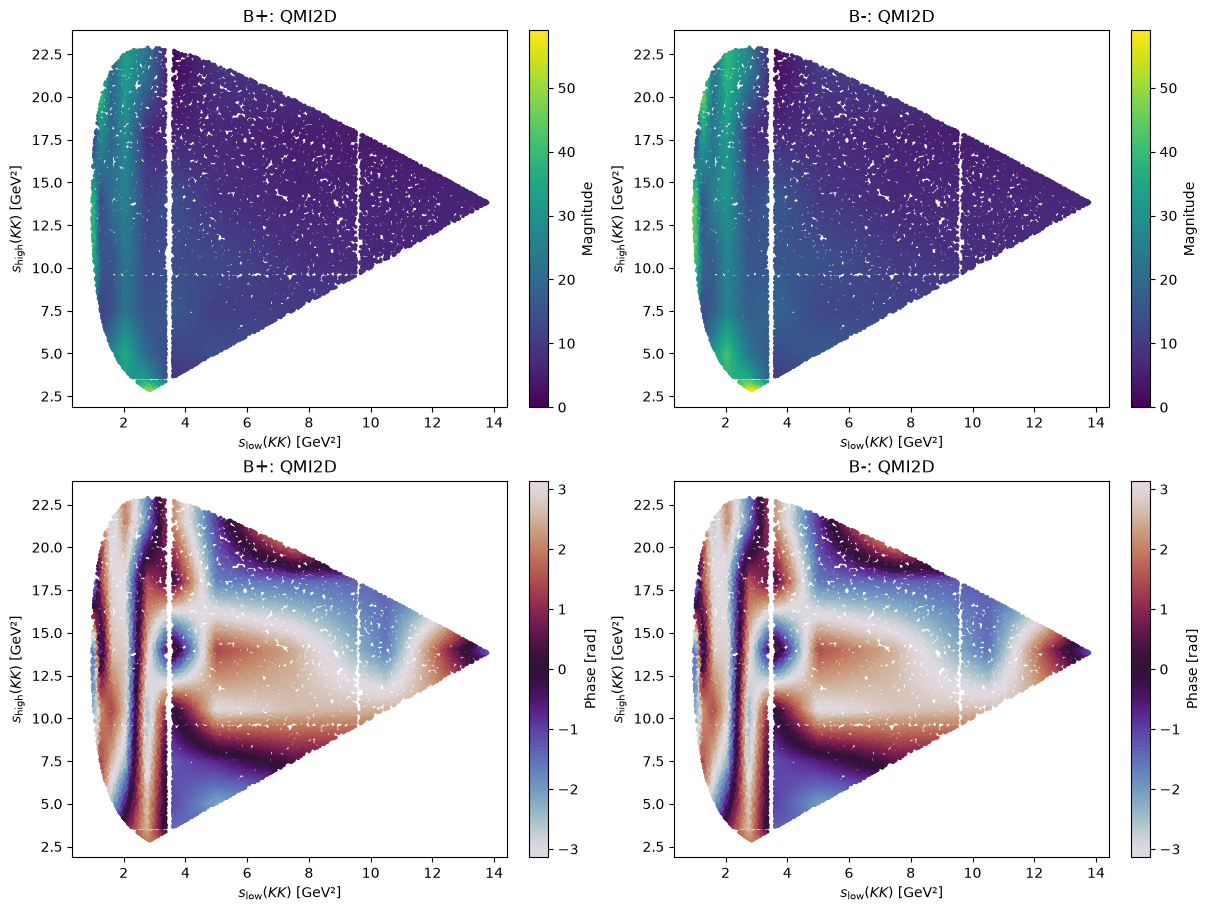

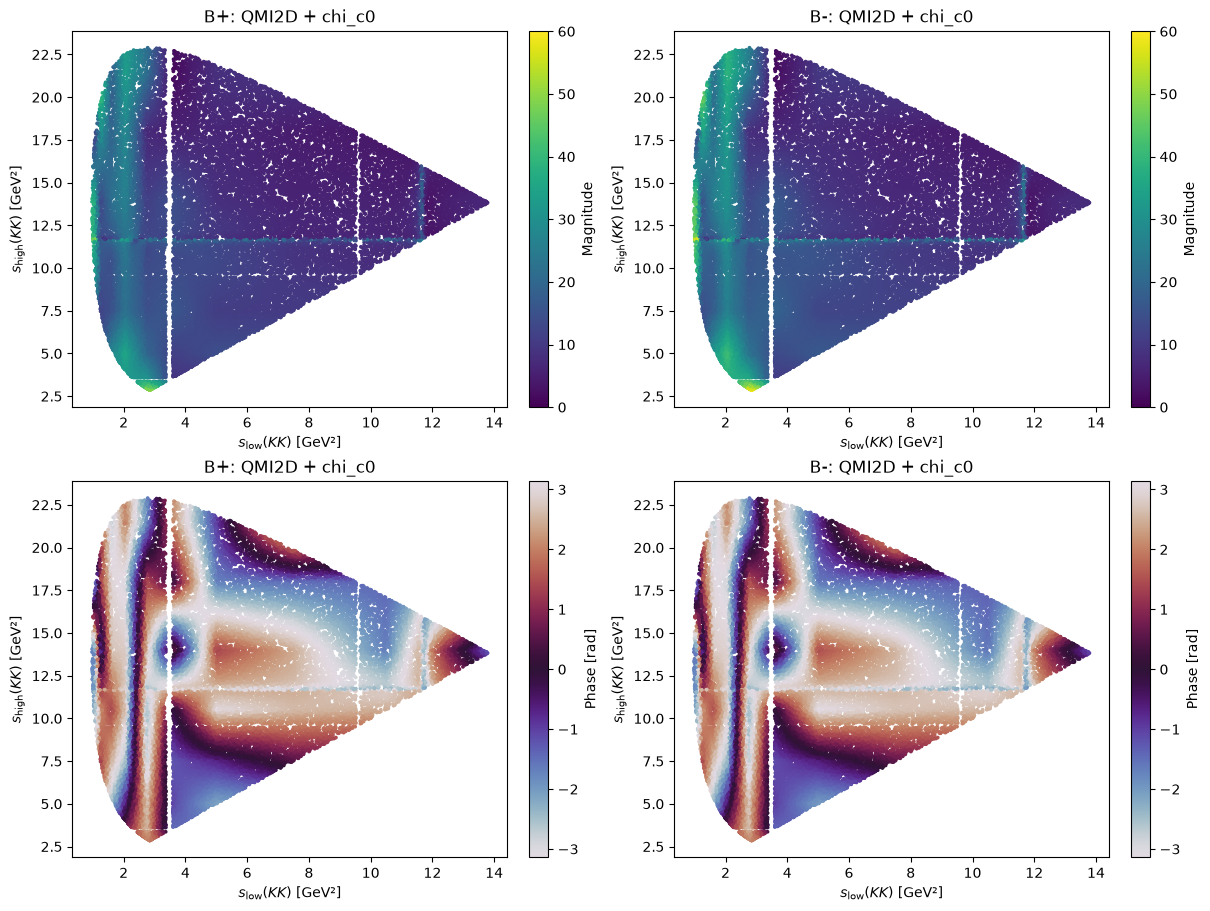

In [16]:
def component_sum_amplitude(model, names, data, values):
    """Coherent sum of the named components' AmplitudeComponent.value(...).

    Uses only the public `model.amplitude_model.components` /
    `AmplitudeComponent.value` API. Safe to skip the per-component
    normalization scale here because this notebook's models are built with
    normalize_components=False throughout (see build_models() above).
    """
    total = None
    for component in model.amplitude_model.components:
        if component.name not in names:
            continue
        contribution = component.value(data, parameters=values, coefficient_values=values)
        total = contribution if total is None else total + contribution
    return jnp.asarray(total)


postfit_qmi2d_values = session.result_values(result)
qmi2d_plot_sample = CHARM_VETO.apply(plus_model.generate_phase_space(
    30_000, seed=FIT_SEED + 8100, include_momenta=False,
))
qmi2d_plot_data = qmi2d_plot_sample.as_dict()
qmi2d_plot_low = np.minimum(qmi2d_plot_sample.s13, qmi2d_plot_sample.s23)
qmi2d_plot_high = np.maximum(qmi2d_plot_sample.s13, qmi2d_plot_sample.s23)


def plot_qmi2d_maps(*, low_max=None):
    selection = np.ones(qmi2d_plot_sample.size, dtype=bool)
    if low_max is not None:
        selection &= qmi2d_plot_low <= low_max
    for include_chic0 in (False, True):
        names = {'QMI2D', 'chi(c0)(1P)'} if include_chic0 else {'QMI2D'}
        amplitudes = [np.asarray(component_sum_amplitude(
            model, names, qmi2d_plot_data, postfit_qmi2d_values,
        ))[selection] for model in (plus_model, minus_model)]
        magnitude_max = max(float(np.max(np.abs(a))) for a in amplitudes)
        fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
        for col, (charge, amplitude) in enumerate(zip(('B+', 'B-'), amplitudes)):
            for row, values in enumerate((np.abs(amplitude), np.angle(amplitude))):
                mesh = axes[row, col].scatter(
                    qmi2d_plot_low[selection], qmi2d_plot_high[selection],
                    c=values, s=3, rasterized=True,
                    cmap='viridis' if row == 0 else 'twilight',
                    vmin=0.0 if row == 0 else -np.pi,
                    vmax=magnitude_max if row == 0 else np.pi,
                )
                axes[row, col].set(
                    xlabel=r'$s_\mathrm{low}(KK)$ [GeV²]',
                    ylabel=r'$s_\mathrm{high}(KK)$ [GeV²]',
                    title=f'{charge}: ' + ('QMI2D + chi_c0' if include_chic0 else 'QMI2D'),
                )
                fig.colorbar(mesh, ax=axes[row, col],
                             label='Magnitude' if row == 0 else 'Phase [rad]')
        plt.show()


plot_qmi2d_maps()


### Zoom em s_low < 4 GeV²

O mesmo mapa bidimensional, restrito à região de baixa massa; s_high permanece livre.


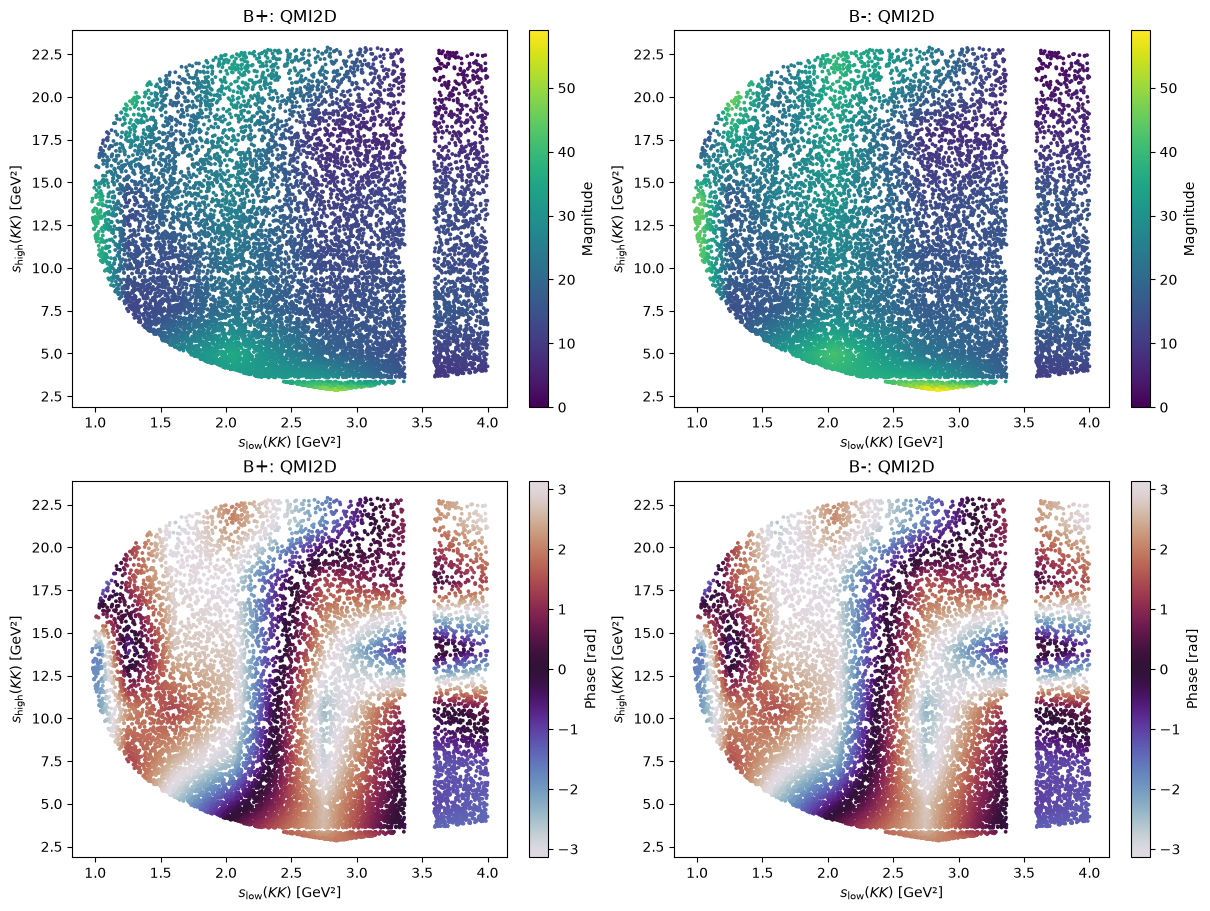

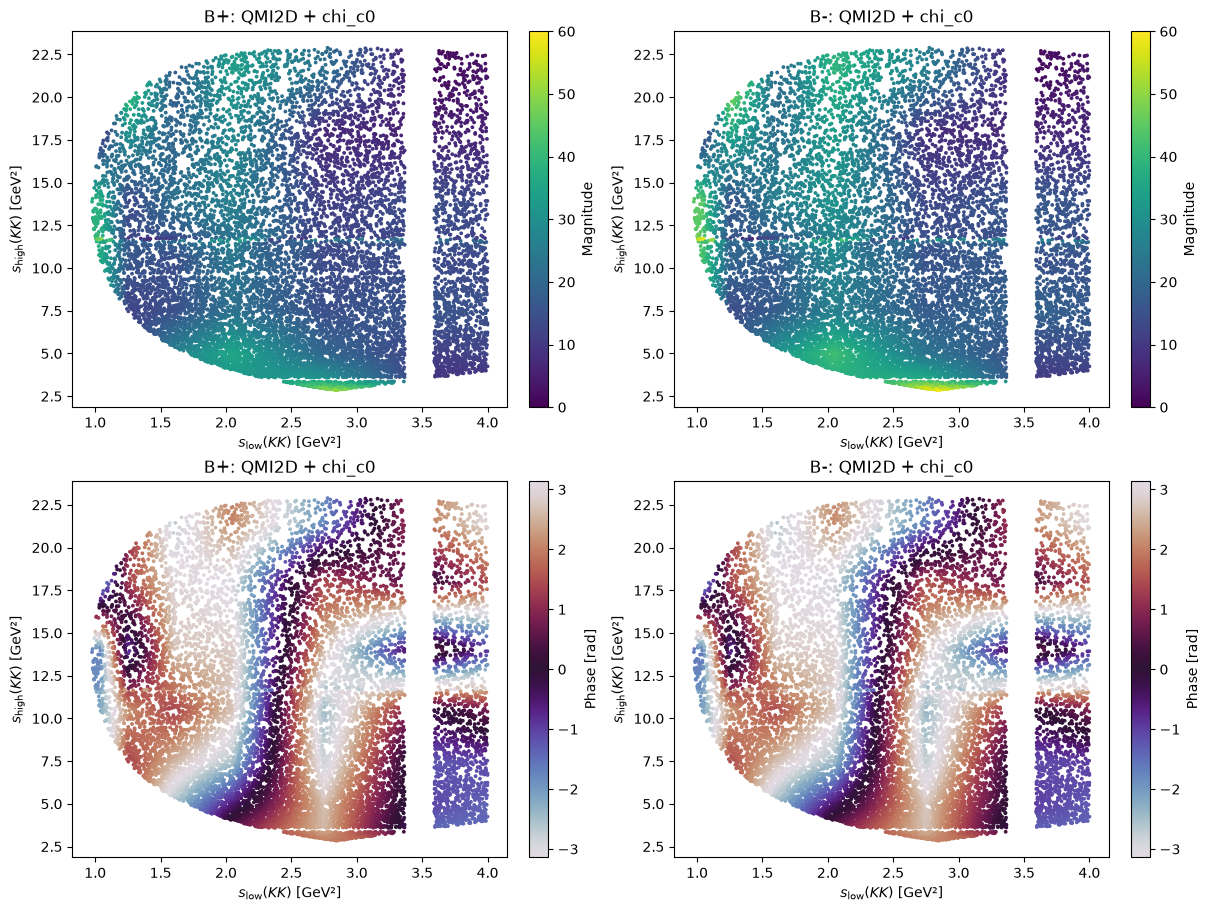

In [17]:
plot_qmi2d_maps(low_max=4.0)

## Postfit diagnostics

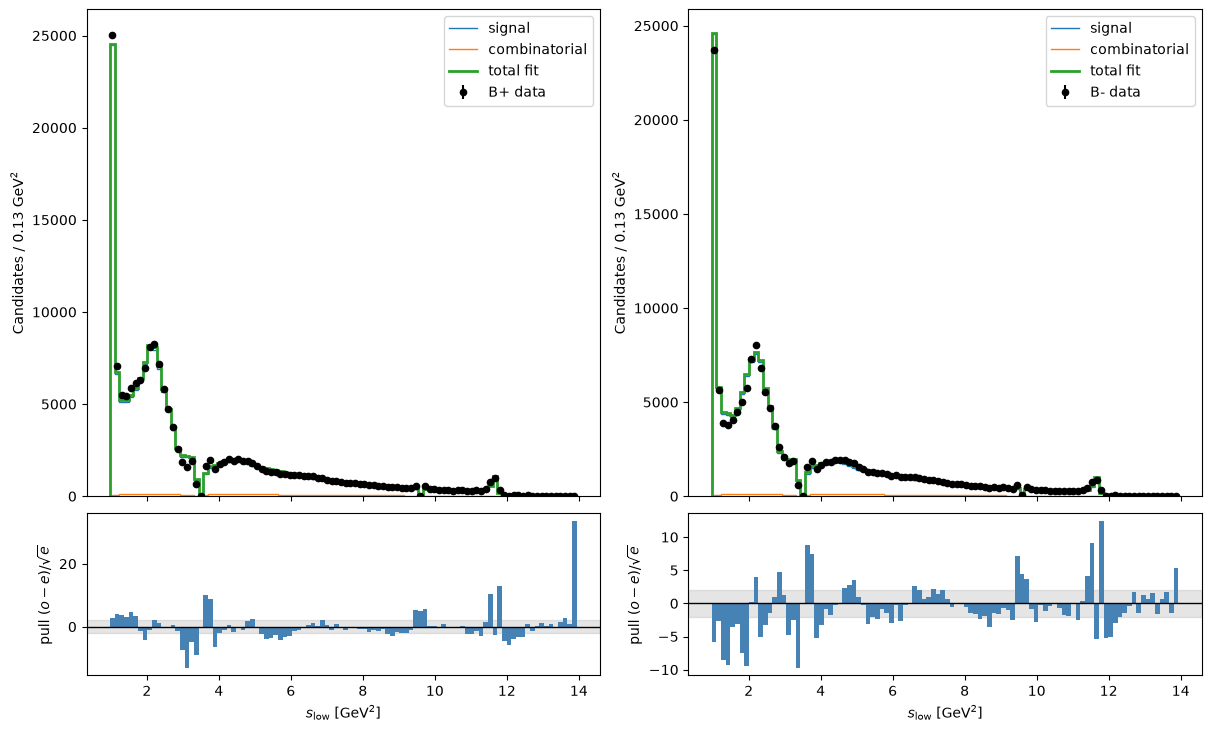

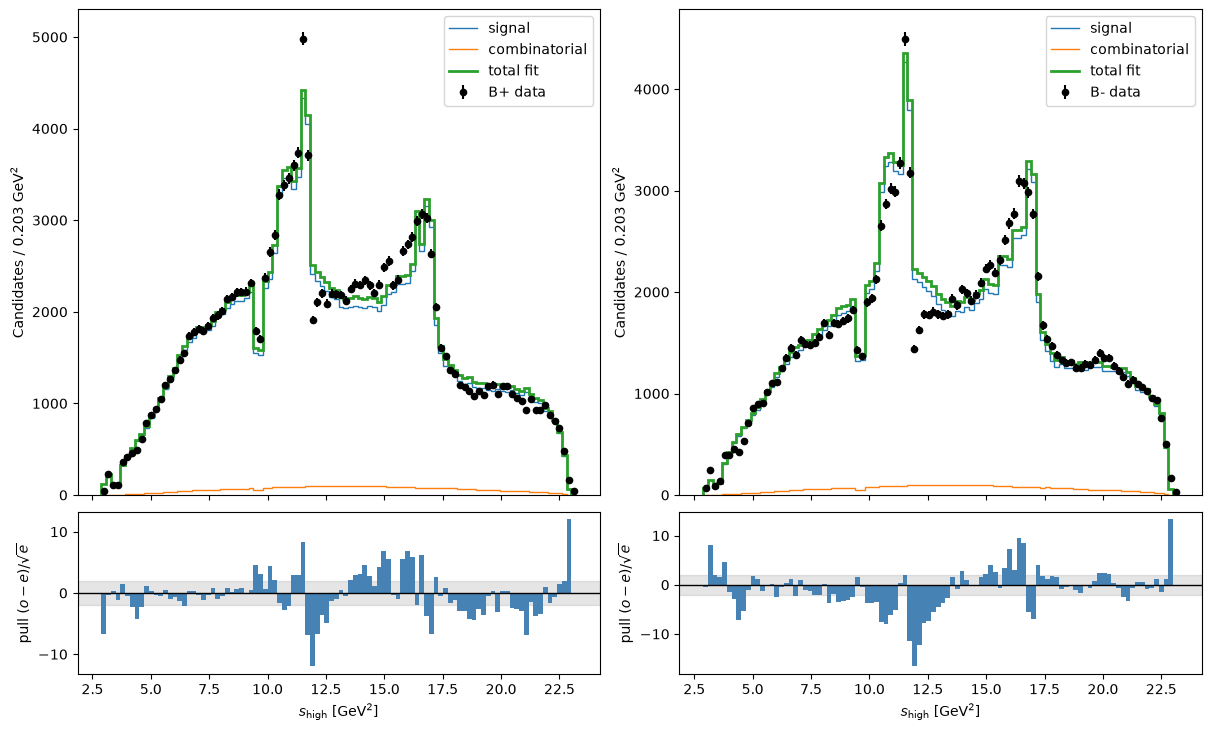

Post-fit: s_low zoom below 4 GeV^2


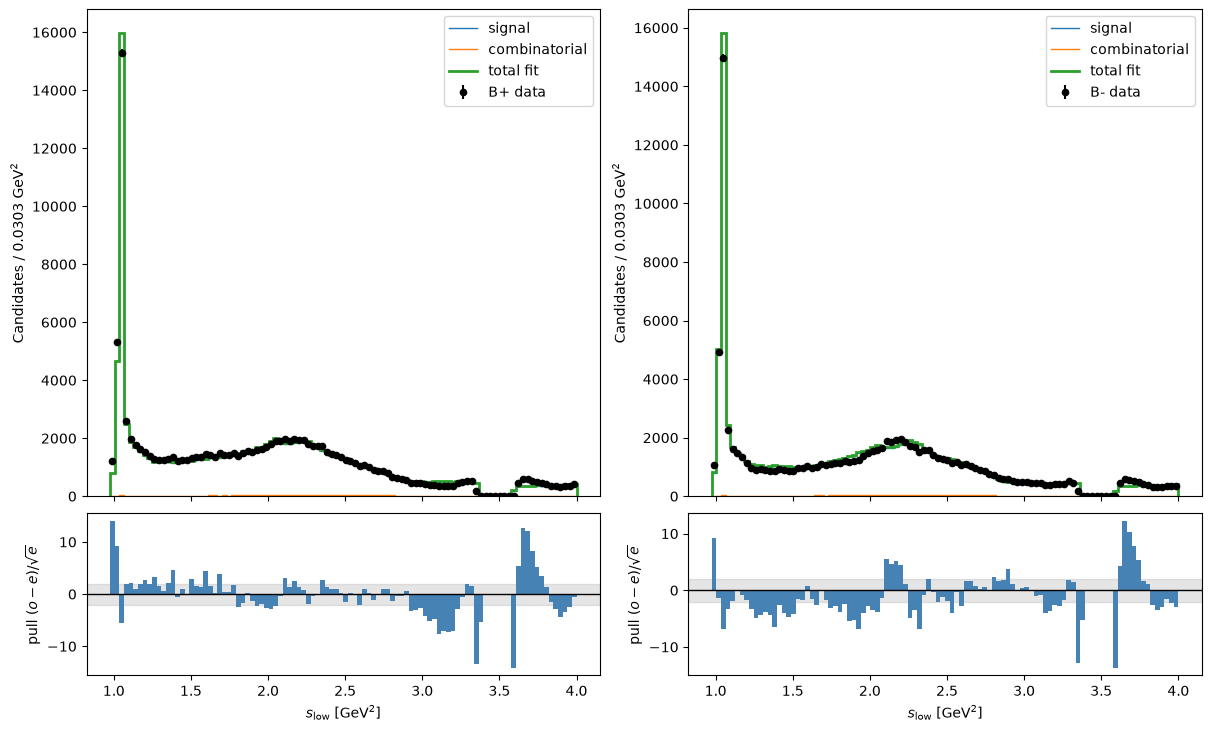

In [18]:
plot_all_diagnostics(
    result,
    title_prefix='Post-fit',
    seed=FIT_SEED + 5000,
)

## Goodness of fit

Quantitative complement to the pull panels above: the binned Pearson chi2 test
(Williams, arXiv:1006.3019, Sec. 3.1) on the folded 1D, plain Dalitz and
Square-Dalitz projections, and the unbinned point-to-point dissimilarity (PPD) test
(Williams Sec. 3.3) per charge. See `docs/goodness_of_fit.md` for the
degrees-of-freedom caveat (the amplitude parameters here come from an unbinned
fit, not from minimizing this chi2, so only a `[dof_min, dof_max]` bound on the
true p-value is available) and the `sigma_bar`/`max_total_events` tuning notes
for PPD.

PPD is `O(n^2)` in the pooled data+reference size, so it cannot run on the full
signal sample (hundreds of thousands of candidates); a dedicated reduced-data
session (`ppd_session`, same fitted models and parameters, a random subsample
of each charge's data) is built below just for that test. The chi2 tests have
no such restriction and run on the full sample, exactly like the projections
above.


Post-fit B+: 1D chi2=816.8 (n_bins=40, dof=[-90,39], p=[nan,3.26e-146])
             Dalitz chi2=5161.6 (n_bins=554, dof=[424,553], p=[0,0])
             SqDP chi2=79441.8 (n_bins=900, dof=[770,899], p=[0,0])


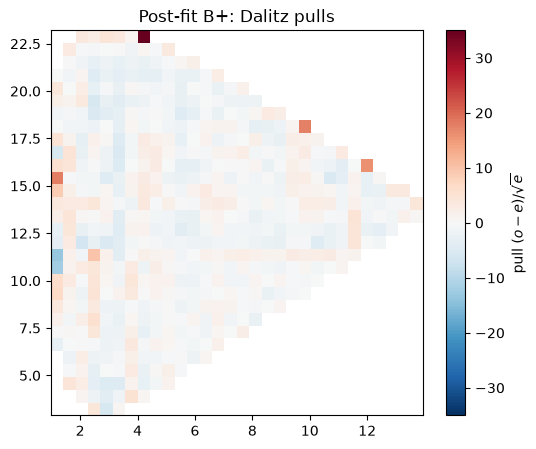

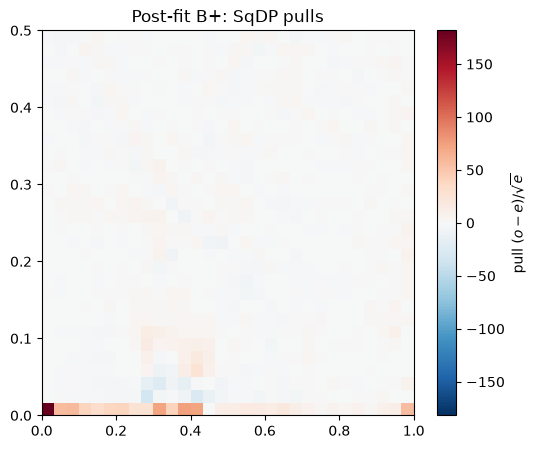

Post-fit B-: 1D chi2=848.9 (n_bins=40, dof=[-90,39], p=[nan,7.1e-153])
             Dalitz chi2=4265.6 (n_bins=557, dof=[427,556], p=[0,0])
             SqDP chi2=117188.6 (n_bins=900, dof=[770,899], p=[0,0])


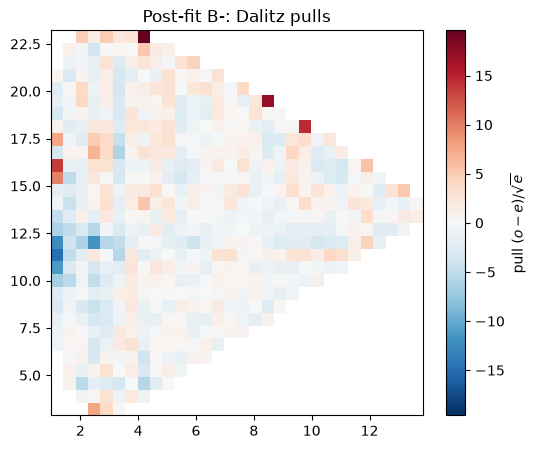

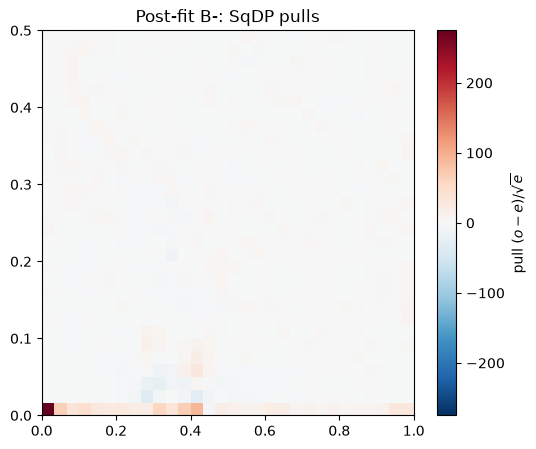

In [19]:
GOF_BINS_1D = 40
GOF_BINS_2D = (30, 30)
PPD_SAMPLE_SIZE = 2000
PPD_MC_SIZE = 3000
# Derived, not duplicated: point_to_point_dissimilarity's own O(n^2) guard
# (default max_total_events=5_000) must never silently drift out of sync
# with the sizes actually requested above.
PPD_MAX_TOTAL_EVENTS = PPD_SAMPLE_SIZE + PPD_MC_SIZE
PPD_PERMUTATIONS = 200
PPD_SEED = FIT_SEED + 7000


def goodness_of_fit_summary(
    fit_result,
    title_prefix,
    bins_1d=GOF_BINS_1D,
    bins_2d=GOF_BINS_2D,
    size=PROJECTION_SIZE,
    seed=FIT_SEED,
):
    """Binned chi2 (folded s_low/s_high 1D, folded SqDP 2D) per charge.

    Bins are chosen independently from `PROJECTION_BINS` (tuned for smooth
    visual projections, not for adequate per-bin occupancy in a chi2 test);
    reduce them if any bins come out empty for the current data/model.
    """
    gof_1d = session.goodness_of_fit_projection(
        fit_result, 's13', bins=bins_1d, folded=True, partner_variable='s23',
        projection_size=size, projection_seed=seed,
    )
    gof_dalitz = session.goodness_of_fit_chi2(
        fit_result, 's13', 's23', folded=True, bins=bins_2d,
        projection_size=size, projection_seed=seed + 1,
    )
    gof_sqdp = session.goodness_of_fit_chi2(
        fit_result, square_dalitz=True, mother_mass=M_B_GEV, masses=DAUGHTER_MASSES,
        pair=SQDP_PAIR, folded=True, bins=bins_2d,
        projection_size=size, projection_seed=seed + 2,
    )

    for charge in ('plus', 'minus'):
        label = f"{title_prefix} B{'+' if charge == 'plus' else '-'}"
        one_d = gof_1d[charge]
        dalitz = gof_dalitz[charge]
        sqdp = gof_sqdp[charge]
        print(
            f"{label}: 1D chi2={one_d.chi2:.1f} (n_bins={one_d.n_bins}, "
            f"dof=[{one_d.dof_min},{one_d.dof_max}], "
            f"p=[{one_d.p_value_min:.3g},{one_d.p_value_max:.3g}])"
        )
        print(
            f"{' ' * len(label)}  Dalitz chi2={dalitz.chi2:.1f} (n_bins={dalitz.n_bins}, "
            f"dof=[{dalitz.dof_min},{dalitz.dof_max}], "
            f"p=[{dalitz.p_value_min:.3g},{dalitz.p_value_max:.3g}])"
        )
        print(
            f"{' ' * len(label)}  SqDP chi2={sqdp.chi2:.1f} (n_bins={sqdp.n_bins}, "
            f"dof=[{sqdp.dof_min},{sqdp.dof_max}], "
            f"p=[{sqdp.p_value_min:.3g},{sqdp.p_value_max:.3g}])"
        )

        for name, two_d in (('Dalitz', dalitz), ('SqDP', sqdp)):
            fig, ax = plt.subplots(figsize=(6, 5))
            plot_pulls(two_d, ax=ax)
            ax.set_title(f'{label}: {name} pulls')
            plt.show()


def ppd_subsample(sample, size, seed):
    """A random unweighted subsample, or the sample unchanged if already small."""
    if sample.size <= size:
        return sample
    rng = np.random.default_rng(seed)
    indices = rng.choice(sample.size, size=size, replace=False)
    return sample.take(jnp.asarray(indices))


def point_to_point_summary(
    fit_result,
    title_prefix,
    sample_size=PPD_SAMPLE_SIZE,
    mc_size=PPD_MC_SIZE,
    n_permutations=PPD_PERMUTATIONS,
    seed=PPD_SEED,
    max_total_events=PPD_MAX_TOTAL_EVENTS,
):
    ppd_session = replace(
        session,
        plus_data=ppd_subsample(samples['plus'], sample_size, seed),
        minus_data=ppd_subsample(samples['minus'], sample_size, seed + 1),
    )
    for charge in ('plus', 'minus'):
        label = f"{title_prefix} B{'+' if charge == 'plus' else '-'}"
        ppd = ppd_session.point_to_point_dissimilarity(
            fit_result, charge=charge, mc_size=mc_size,
            n_permutations=n_permutations, seed=seed + 2,
            max_total_events=max_total_events,
        )
        print(
            f"{label}: PPD statistic={ppd.statistic:.3e}, p={ppd.p_value:.3g} "
            f"(n_data={ppd.n_data} subsample, n_reference={ppd.n_reference})"
        )


goodness_of_fit_summary(result, title_prefix='Post-fit')
# point_to_point_summary(result, title_prefix='Post-fit')


## Folded background and efficiency

Background and efficiency are both built directly from the ROOT files' own
`mPrime`/`thPrime` branches — no invariants-to-square-Dalitz recomputation
or manual mirroring is used to build them.

The two identical \(K^+\) are particles \((0, 1)\) in `('K+', 'K+', 'K-')`;
`SQDP_PAIR = (0, 1)` is exactly this identical pair (verified numerically:
using it to recompute \(m'\)/\(\theta'\) from `s12`/`s13`/`s23` with the
per-candidate mass reproduces the stored ROOT `mPrime`/`thPrime` branches).
`thPrime` in the ROOT files is already folded onto `[0, 0.5]`, so the
histogram is built directly on that half-domain and handed to
`SquareDalitzHistogramBackground`/`SquareDalitzHistogramEfficiency` with
`folded=True`, `pair=SQDP_PAIR` — evaluation (on the fit's own `s12`/`s13`/
`s23`) recomputes \(m'\)/\(\theta'\) internally and folds any query point
onto the same half, so no explicit unfolding/mirroring step is required.

The "Goodness of fit" section's `goodness_of_fit_chi2(square_dalitz=True)`
calls, unlike this background/efficiency construction, always recompute
\(m'\)/\(\theta'\) from `s12`/`s13`/`s23` for *both* data and model --
`CPFitSession` has no hook to substitute the ROOT files' own `mPrime`/
`thPrime` branches for the data side there. The two are numerically close
(see the `SQDP_PAIR` verification note above) but not identical; this is a
deliberate simplification to keep the postfit checks expressed entirely in
terms of the fitter's own public API rather than a second, hand-rolled
recomputation path.

The fit keeps the deterministic `gauss-legendre` normalization actually
configured in `build_models()`, with the same settings for both charges.
The field is folded internally; the integration domain is never halved.
Check normalization convergence when changing the QMI2D binning/interpolation.
